<h3 style='color:#2e6c80;margin-bottom:8px'>FYS-3033: Mandatory Assignment — Problem 1</h3>
<div style='font-size:14px;line-height:1.4;margin-bottom:10px'>
Candidate ID: <i>7429216</i>
<br>
Assignment: <i>Classifying handwritten digit data using both image and audio modalities</i>
<br>
Note: <i>The code for each subsection is implemented as a standalone python script.</i>
</div>

<h3 style='color:#2e6c80;margin-bottom:8px'>Problem 1a: Image-based Unimodal Model</h3>
<div style='font-size:14px;line-height:1.4;margin-bottom:10px'>Design a unimodal model using only the image data.</div>
<ul style='margin-top:0px;margin-bottom:10px;padding-left:20px;font-size:13px;'>
<li>Build and train the model.</li>
<li>Plot training loss and test accuracy.</li>
<li>Display 5 training and 5 test set image samples.</li>
<li>Evaluate and interpret the model’s performance.</li>
</ul>

Using device: mps
Train Images: torch.Size([17560, 1, 28, 28]), Labels: torch.Size([17560])
Test  Images: torch.Size([5859, 1, 28, 28]),  Labels: torch.Size([5859])
Train Images Resize 1-channel: torch.Size([17560, 1, 64, 64]), Labels: torch.Size([17560])
Test  Images Resize 1-channel: torch.Size([5859, 1, 64, 64]),  Labels: torch.Size([5859])
Train Images Resize 3-channel: torch.Size([17560, 3, 64, 64]), Labels: torch.Size([17560])
Test  Images Resize 3-channel: torch.Size([5859, 3, 64, 64]),  Labels: torch.Size([5859])


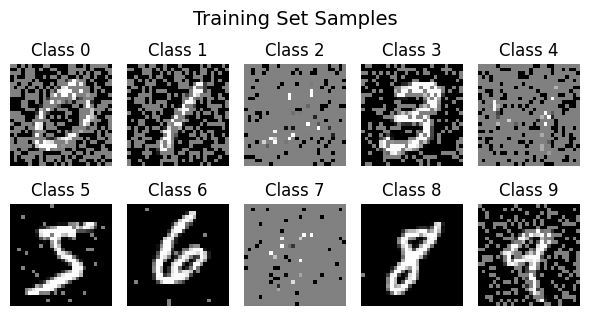

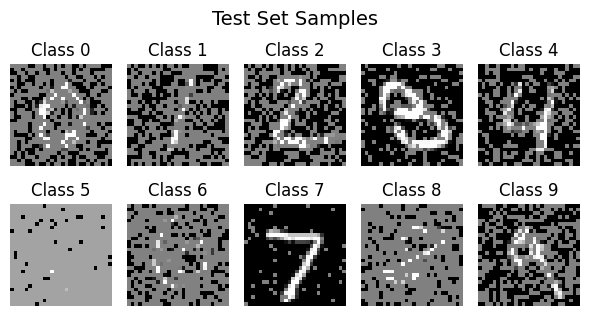

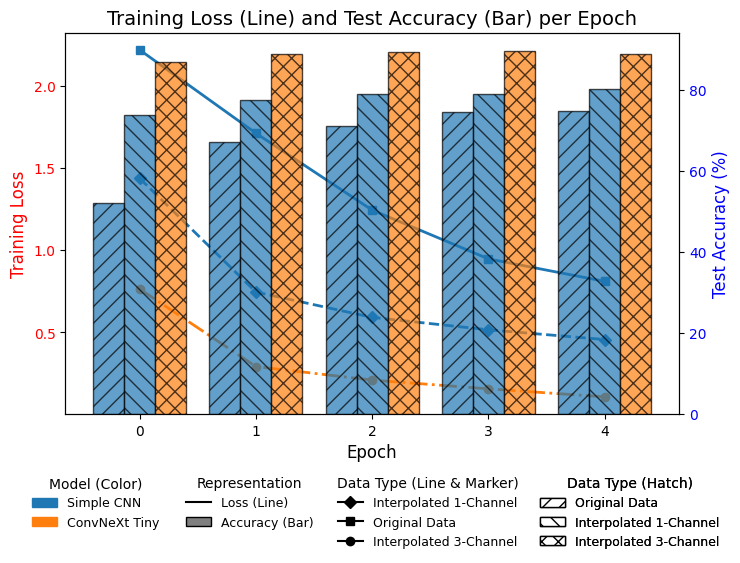


Visual Results:
| Modality   | Data Type              | Model         | Train Accuracy   | Test Accuracy   | Training Time   |
|------------|------------------------|---------------|------------------|-----------------|-----------------|
| Visual     | Original Data          | Simple CNN    | 79.01%           | 74.71%          | 13.39s          |
| Visual     | Interpolated 1-Channel | Simple CNN    | 88.64%           | 80.20%          | 43.16s          |
| Visual     | Interpolated 3-Channel | ConvNeXt Tiny | 97.59%           | 88.85%          | 123.13s         |


In [28]:
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import timm
import matplotlib.pyplot as plt
from tqdm import tqdm
from tabulate import tabulate
import numpy as np
import itertools
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
# ------------------- Constants & Hyperparameters -------------------
DATA_DIR = "data"
BATCH_SIZE = 64
LEARNING_RATE = 1e-5
NUM_EPOCHS = 5
NUM_CLASSES = 10
MODELS = {
    "Simple CNN": "simpleCNN",
    "ConvNeXt Tiny": "convnext_tiny"
}
DATA_TYPES = {
    "Original Data": "original",
    "Interpolated 1-Channel": "interpolated_1-channel",
    "Interpolated 3-Channel": "interpolated_3-channel"
}
RESULTS_DIR = "NLDL_FYS-8604/images"
# ------------------- Device Setup -------------------
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

# ------------------- Data Handling -------------------
def batched_resize(x, size=224, batch_size=64):
    resized = []
    for i in range(0, x.size(0), batch_size):
        batch = x[i:i+batch_size]
        resized_batch = F.interpolate(batch, size=(size, size), mode='bilinear', align_corners=False)
        resized.append(resized_batch)
    return torch.cat(resized, dim=0)

def resize(x, size=224):
    """Resize images to the specified size."""
    return F.interpolate(x, size=(size, size), mode='bilinear', align_corners=False)

def repeat(x): # for pre-trained models
    """Repeat the input tensor to match the expected input shape for pre-trained models."""
    return x.repeat(1, 3, 1, 1)

def load_visual_data(data_dir):
    train_images = torch.load(f"{data_dir}/training_images.pth")
    train_labels = torch.load(f"{data_dir}/training_images_labels.pth")
    test_images = torch.load(f"{data_dir}/test_images.pth")
    test_labels = torch.load(f"{data_dir}/test_images_labels.pth")
    return train_images, train_labels, test_images, test_labels

def create_dataloaders(train_data, test_data, batch_size):
    train_loader = DataLoader(TensorDataset(*train_data), batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(TensorDataset(*test_data), batch_size=batch_size, shuffle=False)
    return train_loader, test_loader

# ------------------- Plotting Functions -------------------
def plot_visual_samples(images, labels, classes=10, title=""):
    """Display the first image of each class in a 2x5 grid."""
    fig, axes = plt.subplots(2, 5, figsize=(6, 3.5))
    fig.suptitle(title, fontsize=14, y=0.95)
    shown = set()
    idx = 0
    for i, label in enumerate(labels):
        label = label.item()
        if label not in shown:
            img = images[i].squeeze().numpy()
            ax = axes[idx // 5][idx % 5]
            ax.imshow(img, cmap='gray')
            ax.set_title(f"Class {label}")
            ax.axis('off')
            shown.add(label)
            idx += 1
        if len(shown) == classes:
            break
    plt.tight_layout()
    plt.show()

def plot_combined_loss_and_accuracy(models_results, dir="NLDL_FYS-8604/images", plot_name="results"):
    num_epochs = len(models_results[0]['train_loss'])
    num_models = len(models_results)
    epoch_indices = np.arange(num_epochs)

    fig, ax1 = plt.subplots(figsize=(10, 6))
    ax2 = ax1.twinx()
    # Style setup
    color_cycle = plt.cm.tab10.colors
    line_style_cycle = ['-', '--', '-.', ':']
    hatch_base = ['/', '\\', 'x', '-', '+', '.', '*', 'O']
    hatch_cycle = itertools.cycle([h*2 for h in hatch_base])  # Dense hatch
    line_styles = itertools.cycle(line_style_cycle)

    # Unique models, colors, data types and markers
    unique_model_names = list({model['name'] for model in models_results})
    color_map = {name: color_cycle[i % len(color_cycle)] for i, name in enumerate(unique_model_names)}
    data_types = list({model.get('data_type', f"Data {i+1}") for i, model in enumerate(models_results)})
    marker_cycle = ['o', 's', 'D', '^', 'v', '<', '>', 'P', '*', 'X']
    data_type_to_marker = {dt: marker_cycle[i % len(marker_cycle)] for i, dt in enumerate(data_types)}
    # Bar width and offset
    bar_width = 0.8 / num_models
    offset = - (num_models - 1) / 2 * bar_width
    # Legend handles
    model_handles = {}
    hatch_handles = {}
    line_style_handle = Line2D([0], [0], color='black', linestyle='-', label='Loss (Line)')
    bar_style_handle = Patch(facecolor='gray', edgecolor='black', label='Accuracy (Bar)')
    # Bars (accuracy)
    for i, model in enumerate(models_results):
        model_name = model['name']
        data_type = model.get('data_type', f"Data {i+1}")
        color = color_map[model_name]
        hatch = next(hatch_cycle)
        acc = np.array(model['test_accuracy'])
        bar_positions = epoch_indices + (i * bar_width) + offset

        ax2.bar(bar_positions, acc, width=bar_width, color=color,
                alpha=0.7, edgecolor='black', hatch=hatch, zorder=1)

        if model_name not in model_handles:
            model_handles[model_name] = Patch(color=color, label=model_name)
        if data_type not in hatch_handles:
            hatch_handles[data_type] = Patch(facecolor='white', edgecolor='black', hatch=hatch, label=data_type)
    # Lines (loss)
    line_styles = itertools.cycle(line_style_cycle)
    for i, model in enumerate(models_results):
        model_name = model['name']
        data_type = model.get('data_type', f"Data {i+1}")
        color = color_map[model_name]
        marker = data_type_to_marker[data_type]
        line_style = next(line_styles)
        ax1.plot(epoch_indices, model['train_loss'],
                 linestyle=line_style, marker=marker,
                 color=color, linewidth=2, markersize=6, zorder=3)
    # Labels and ticks
    ax1.set_xlabel("Epoch", fontsize=12)
    ax1.set_ylabel("Training Loss", color='red', fontsize=12)
    ax2.set_ylabel("Test Accuracy (%)", color='blue', fontsize=12)
    ax1.tick_params(axis='y', labelcolor='red')
    ax2.tick_params(axis='y', labelcolor='blue')
    ax1.set_xticks(epoch_indices)
    plt.title("Training Loss (Line) and Test Accuracy (Bar) per Epoch", fontsize=14)
    # Legends
    model_legend = ax1.legend(
        handles=list(model_handles.values()),
        title='Model (Color)',
        loc='lower center',
        bbox_to_anchor=(0.05, -0.33),
        fontsize=9,
        title_fontsize=10,
        frameon=False
    )
    ax1.add_artist(model_legend)
    representation_legend = ax1.legend(
        handles=[line_style_handle, bar_style_handle],
        title='Representation',
        loc='lower center',
        bbox_to_anchor=(0.3, -0.33),
        fontsize=9,
        title_fontsize=10,
        frameon=False
    )
    ax1.add_artist(representation_legend)
    data_type_handles = []
    for dt in data_types:
        marker = data_type_to_marker[dt]
        handle = Line2D([0], [0], color='black', marker=marker, linestyle='-', label=dt, markersize=6)
        data_type_handles.insert(0, handle)
    data_type_legend = ax1.legend(
        handles=data_type_handles,
        title='Data Type (Line & Marker)',
        loc='lower center',
        bbox_to_anchor=(0.59, -0.38),
        fontsize=9,
        title_fontsize=10,
        frameon=False
    )
    ax1.add_artist(data_type_legend)
    hatch_legend = ax1.legend(
        handles=list(hatch_handles.values()),
        title='Data Type (Hatch)',
        loc='lower center',
        bbox_to_anchor=(0.92, -0.38),
        fontsize=9,
        title_fontsize=10,
        frameon=False
    )
    ax1.add_artist(hatch_legend)
    # Layout adjustments
    fig.tight_layout(rect=[0, 0.35, 0.75, 0.75])
    plt.subplots_adjust(bottom=0.05)
    # Save the figure as a PNG, including all extra legends
    plt.title("", fontsize=0)
    fig.canvas.draw()
    extra_legends = [model_legend, representation_legend, data_type_legend, hatch_legend]
    fig.savefig(
        f"{dir}/{plot_name}.png",
        dpi=300,
        bbox_inches='tight',
        bbox_extra_artists=extra_legends
    )
    plt.title("Training Loss (Line) and Test Accuracy (Bar) per Epoch", fontsize=14)
    plt.show()

# ------------------- Models ---------------------
class preTrainedCNNModel(nn.Module):
    """Pre-trained CNN model using timm library."""
    def __init__(self, model_name, num_classes):
        super().__init__()
        self.model = timm.create_model(model_name, pretrained=True, num_classes=num_classes)

    def forward(self, x):
        return self.model(x)

class simpleCNN(nn.Module):
    """Simple CNN Encoder from the 1st practice in the course """
    def __init__(self, num_classes=10, prj_dim=4096):
        super(simpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.proj  = nn.Sequential(nn.LazyLinear(prj_dim), nn.ReLU())
        self.fc1   = nn.LazyLinear(num_classes)  # Use LazyLinear to define later based on input size

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Input shape:    [batch_size, 1, W, H]
        Output shape:   [batch_size, 64 * W/4 * H/4]
        Example of Visual:          [64, 1, 28, 28]  -> [64, 64 * 7 * 7]  = [64, 3136]
        Example of Melspectrogram:  [64, 1, 32, 201] -> [64, 64 * 8 * 50] = [64, 25600]
        """
        x = F.relu(self.conv1(x))   # [batch_size, 32, W, H]
        x = F.max_pool2d(x, 2)      # [batch_size, 32, W/2, H/2]
        x = F.relu(self.conv2(x))   # [batch_size, 64, W/2, H/2]
        x = F.max_pool2d(x, 2)      # [batch_size, 64, W/4, H/4]
        x = x.view(x.size(0), -1)   # Flatten: [batch_size, 64 * W/4 * H/4] 
        x = self.proj(x)            # Project: [batch_size, prj_dim]
        x = self.fc1(x)
        return x

# ------------------- Training and Evaluation -------------------
def train_and_evaluate(model, train_loader, test_loader, infor, num_epochs, learning_rate):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    train_losses = []
    test_accuracies = []

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        progress_bar = tqdm(train_loader, leave=False, desc=f"{infor['model_name']}-{infor['data_type']} Epoch {epoch+1}")
        for x, y in progress_bar:
            x, y = x.to(device), y.to(device)
            outputs = model(x)
            loss = criterion(outputs, y)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            avg_loss = total_loss / (progress_bar.n + 1)
            progress_bar.set_postfix(loss=f"{avg_loss:.4f}")      
        train_losses.append(avg_loss)
        test_accuracy = evaluate(model, test_loader)
        test_accuracies.append(test_accuracy)
    train_accuracy = evaluate(model, train_loader)
    return train_accuracy, train_losses, test_accuracies

def evaluate(model, test_loader):
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            outputs = model(x)
            _, preds = torch.max(outputs, 1)
            correct += (preds == y).sum().item()
            total += y.size(0)
    accuracy = 100 * correct / total
    return accuracy

# ------------------- Experiment Runner -------------------
def run_experiments():
    train_images_data, train_images_labels, test_images_data, test_images_labels = load_visual_data(DATA_DIR)
    train_images_1channel, test_images_1channel = batched_resize(train_images_data, BATCH_SIZE), batched_resize(test_images_data, BATCH_SIZE)
    train_images_3channel, test_images_3channel = repeat(train_images_1channel), repeat(test_images_1channel)
    train_loader_origin, test_loader_origin     = create_dataloaders((train_images_data, train_images_labels), (test_images_data, test_images_labels), BATCH_SIZE)
    train_loader_1channel, test_loader_1channel = create_dataloaders((train_images_1channel, train_images_labels), (test_images_1channel, test_images_labels), BATCH_SIZE)
    train_loader_3channel, test_loader_3channel = create_dataloaders((train_images_3channel, train_images_labels), (test_images_3channel, test_images_labels), BATCH_SIZE)
    print(f"Train Images: {train_images_data.shape}, Labels: {train_images_labels.shape}")
    print(f"Test  Images: {test_images_data.shape},  Labels: {test_images_labels.shape}")
    print(f"Train Images Resize 1-channel: {train_images_1channel.shape}, Labels: {train_images_labels.shape}")
    print(f"Test  Images Resize 1-channel: {test_images_1channel.shape},  Labels: {test_images_labels.shape}")
    print(f"Train Images Resize 3-channel: {train_images_3channel.shape}, Labels: {train_images_labels.shape}")
    print(f"Test  Images Resize 3-channel: {test_images_3channel.shape},  Labels: {test_images_labels.shape}")
    plot_visual_samples(train_images_data, train_images_labels, title="Training Set Samples")
    plot_visual_samples(test_images_data, test_images_labels, title="Test Set Samples")
    results = []
    for data_name, data_type in DATA_TYPES.items():
        for model_name, model in MODELS.items():
            if (model == "simpleCNN" and data_type == "interpolated_3-channel") or (model != "simpleCNN" and data_type != "interpolated_3-channel"):
                continue
            model  = simpleCNN(NUM_CLASSES)   if model == "simpleCNN" else preTrainedCNNModel(model, NUM_CLASSES)
            train_loader = train_loader_origin if data_type == "original" else (
                train_loader_1channel if data_type == "interpolated_1-channel" else train_loader_3channel
            )
            test_loader = test_loader_origin if data_type == "original" else (
                test_loader_1channel if data_type == "interpolated_1-channel" else test_loader_3channel
            )
            info = { 'model_name': model_name, 'data_type': data_type}
            start_time   = time.time()
            train_accuracy, train_losses, test_accuracies = train_and_evaluate(model, train_loader, test_loader, info, NUM_EPOCHS, LEARNING_RATE)
            elapsed_time = time.time() - start_time
            results.append({
                'name': model_name,
                'data_type': data_name,
                'train_loss': train_losses,
                'test_accuracy': test_accuracies,
                'train_acc_final': f"{train_accuracy:.2f}%",
                'test_acc_final': f"{test_accuracies[-1]:.2f}%",
                'training_time': f"{elapsed_time:.2f}s"
            })
    return results
    
# ------------------- Entry Point -------------------
if __name__ == "__main__":
    visual_results = run_experiments()

    plot_combined_loss_and_accuracy(visual_results, dir=RESULTS_DIR, plot_name="visual_results")

    print("\nVisual Results:")
    visual_summary_table = [
        ['Visual', r['data_type'], r['name'], r['train_acc_final'], r['test_acc_final'], r['training_time']]  for r in visual_results
    ]
    print(tabulate(visual_summary_table, headers=["Modality", "Data Type", "Model", "Train Accuracy", "Test Accuracy", "Training Time"], tablefmt="github"))


<h3 style='color:#2e6c80;margin-bottom:8px'>Problem 1b: Audio-based Unimodal Model</h3>
<div style='font-size:14px;line-height:1.4;margin-bottom:10px'>Repeat 1a using only the audio data.</div>
<ul style='margin-top:0px;margin-bottom:10px;padding-left:20px;font-size:13px;'>
<li>Plot training loss and test accuracy.</li>
<li>Display 5 audio samples from training and test sets.</li>
<li>Evaluate and interpret the model’s performance.</li>
</ul>

Using device: mps
Train Audios: torch.Size([17560, 1, 32, 201]), Labels: torch.Size([17560])
Test  Audios: torch.Size([5859, 1, 32, 201]),  Labels: torch.Size([5859])
Train Audios Resize 1-channel: torch.Size([17560, 1, 64, 64]), Labels: torch.Size([17560])
Test  Audios Resize 1-channel: torch.Size([5859, 1, 64, 64]),  Labels: torch.Size([5859])
Train Audios Resize 3-channel: torch.Size([17560, 3, 64, 64]), Labels: torch.Size([17560])
Test  Audios Resize 3-channel: torch.Size([5859, 3, 64, 64]),  Labels: torch.Size([5859])


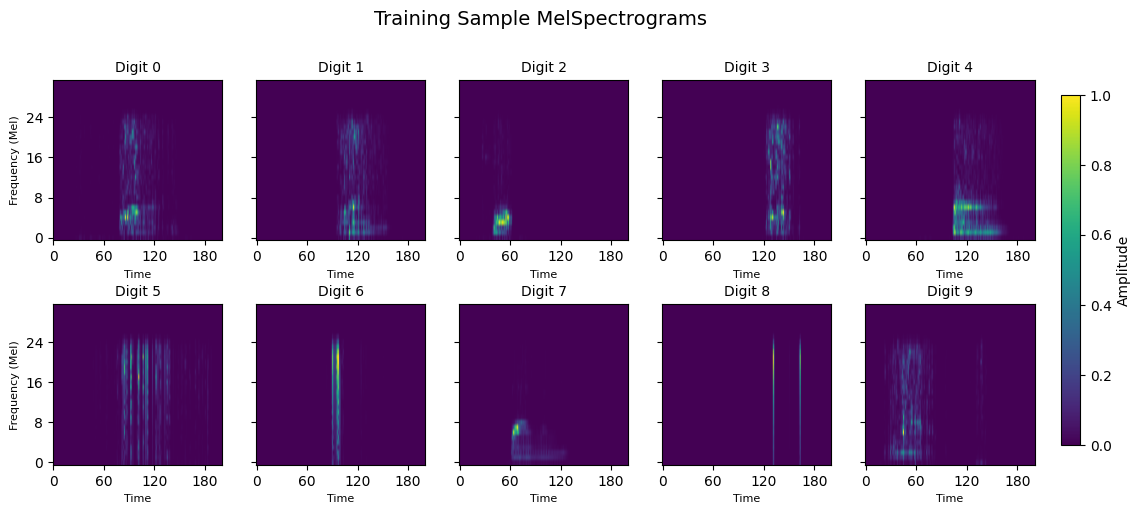

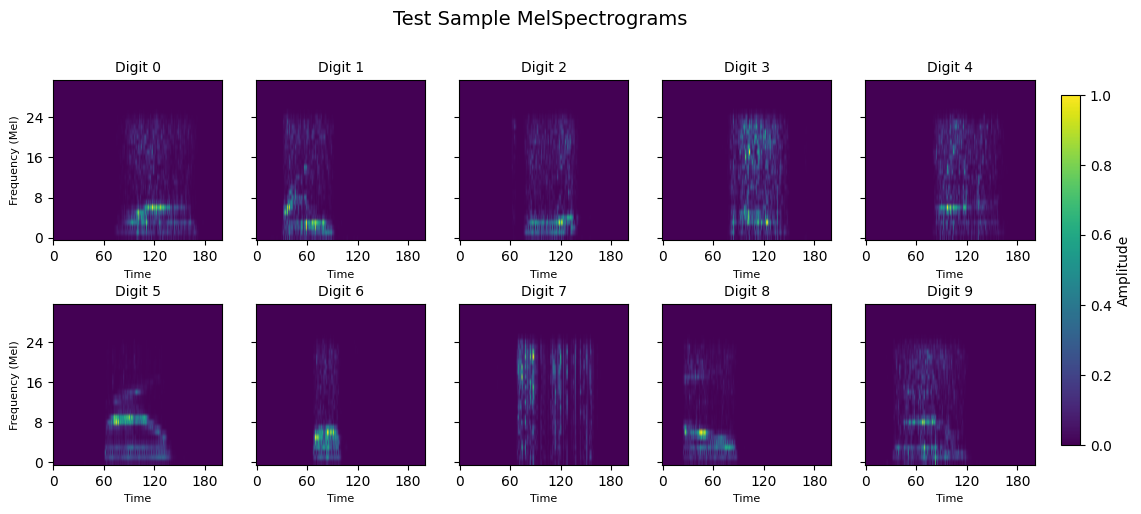

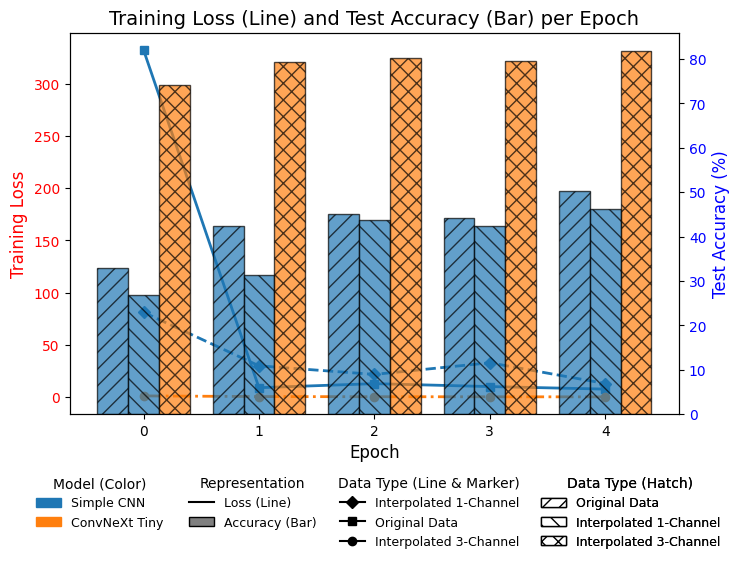


Audio Results:
| Modality   | Data Type              | Model         | Train Accuracy   | Test Accuracy   | Training Time   |
|------------|------------------------|---------------|------------------|-----------------|-----------------|
| Audio      | Original Data          | Simple CNN    | 59.64%           | 50.25%          | 64.67s          |
| Audio      | Interpolated 1-Channel | Simple CNN    | 52.59%           | 46.25%          | 42.49s          |
| Audio      | Interpolated 3-Channel | ConvNeXt Tiny | 94.40%           | 81.84%          | 122.88s         |


In [13]:
import time
import torch
import torch.nn as nn
import torch.optim as optim
import torchaudio.transforms as T
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from tqdm import tqdm
from tabulate import tabulate
import timm
import numpy as np
import itertools
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
# ------------------- Configuration -------------------
DATA_DIR = "data"
BATCH_SIZE = 64
NUM_EPOCHS = 5
LEARNING_RATE = 1e-5
NUM_CLASSES = 10
ORIG_SAMPLE_RATE = 8000
TARGET_SAMPLE_RATE = 16000
MODELS = {
    "ConvNeXt Tiny": "convnext_tiny",
    "Simple CNN": "simpleCNN",
    #"ConvNeXt Tiny": "convnext_tiny"
}
DATA_TYPES = {
    "Original Data": "original",
    "Interpolated 1-Channel": "interpolated_1-channel",
    "Interpolated 3-Channel": "interpolated_3-channel"
}
RESULTS_DIR = "NLDL_FYS-8604/images"
# ------------------- Device -------------------
device = torch.device("cuda" if torch.cuda.is_available()
                      else "mps" if torch.backends.mps.is_available()
                      else "cpu")
print(f"Using device: {device}")

# -------------------  Data Handling -------------------
def batched_resize(x, size=224, batch_size=64):
    resized = []
    for i in range(0, x.size(0), batch_size):
        batch = x[i:i+batch_size]
        resized_batch = F.interpolate(batch, size=(size, size), mode='bilinear', align_corners=False)
        resized.append(resized_batch)
    return torch.cat(resized, dim=0)

def resize(x, size=224):
    """Resize images to the specified size."""
    return F.interpolate(x, size=(size, size), mode='bilinear', align_corners=False)

def repeat(x): # for pre-trained models
    """Repeat the input tensor to match the expected input shape for pre-trained models."""
    return x.repeat(1, 3, 1, 1)

def transform_mel(audio_data):
    mel_transform = T.MelSpectrogram(
        sample_rate=TARGET_SAMPLE_RATE,
        n_fft=256,
        hop_length=80,
        n_mels=32,
        normalized=True
    )
    mel_spectrograms = torch.stack([mel_transform(wf) for wf in audio_data])
    return mel_spectrograms

def resample_audio(train_audio_data, test_audio_data):
    resampler = T.Resample(orig_freq=ORIG_SAMPLE_RATE, new_freq=TARGET_SAMPLE_RATE)
    train_audio_resampled = torch.stack([resampler(wf.float()) for wf in train_audio_data])
    test_audio_resampled = torch.stack([resampler(wf.float()) for wf in test_audio_data])
    return train_audio_resampled, test_audio_resampled

def load_audio_data(data_dir): # from 8000 to 16000 Hz
    train_audio_data   = torch.load(f"{data_dir}/training_audio.pth")
    train_audio_labels = torch.load(f"{data_dir}/training_audio_labels.pth")
    test_audio_data    = torch.load(f"{data_dir}/test_audio.pth")
    test_audio_labels  = torch.load(f"{data_dir}/test_audio_labels.pth")
    train_audio_data, test_audio_data = resample_audio(train_audio_data, test_audio_data)
    train_audio_mels, test_audio_mels = transform_mel(train_audio_data), transform_mel(test_audio_data)
    return train_audio_mels, train_audio_labels, test_audio_mels, test_audio_labels

def create_dataloaders(train_data, test_data, batch_size):
    train_loader = DataLoader(TensorDataset(*train_data), batch_size=batch_size, shuffle=True)
    test_loader  = DataLoader(TensorDataset(*test_data), batch_size=batch_size, shuffle=False)
    return train_loader, test_loader

# ------------------- Plotting Functions -------------------
def plot_spectrogram_samples(mel_spectrograms, labels, classes=10, title=""):
    """Plot one MelSpectrogram per class in a 2x5 grid, with one frequency label per row, time labels, and enhanced color intensity."""
    fig, axes = plt.subplots(2, 5, figsize=(13, 5))
    fig.suptitle(title, fontsize=14, y=1.02)
    shown = set()
    idx = 0
    im = None  # for colorbar
    for i in range(len(labels)):
        label = labels[i].item()
        if label not in shown:
            spec = mel_spectrograms[i].squeeze().numpy()
            # Normalize spectrogram to [0, 1] for better color contrast
            spec = (spec - np.min(spec)) / (np.max(spec) - np.min(spec) + 1e-6)
            row = idx // 5
            col = idx % 5
            ax = axes[row][col]
            im = ax.imshow(spec, origin="lower", aspect="auto", cmap="viridis", vmin=0, vmax=1)
            ax.set_title(f"Digit {label}", fontsize=10)
            # Frequency label only for leftmost subplot in each row
            if col == 0:
                ax.set_ylabel("Frequency (Mel)", fontsize=8)
            else:
                ax.set_yticklabels([])
                ax.set_ylabel("")
            # Time label for all
            ax.set_xlabel("Time", fontsize=8)
            ax.xaxis.set_major_locator(plt.MaxNLocator(4))
            ax.yaxis.set_major_locator(plt.MaxNLocator(4))
            shown.add(label)
            idx += 1
        if len(shown) == classes:
            break
    # Adjust layout for colorbar
    plt.subplots_adjust(right=0.88, hspace=0.4, wspace=0.2)
    cbar_ax = fig.add_axes([0.9, 0.15, 0.015, 0.7])
    cbar = fig.colorbar(im, cax=cbar_ax)
    cbar.set_label("Amplitude", fontsize=10)
    plt.show()

def plot_combined_loss_and_accuracy(models_results, dir="NLDL_FYS-8604/images", plot_name="results"):
    num_epochs = len(models_results[0]['train_loss'])
    num_models = len(models_results)
    epoch_indices = np.arange(num_epochs)

    fig, ax1 = plt.subplots(figsize=(10, 6))
    ax2 = ax1.twinx()
    # Style setup
    color_cycle = plt.cm.tab10.colors
    line_style_cycle = ['-', '--', '-.', ':']
    hatch_base = ['/', '\\', 'x', '-', '+', '.', '*', 'O']
    hatch_cycle = itertools.cycle([h*2 for h in hatch_base])  # Dense hatch
    line_styles = itertools.cycle(line_style_cycle)

    # Unique models, colors, data types and markers
    unique_model_names = list({model['name'] for model in models_results})
    color_map = {name: color_cycle[i % len(color_cycle)] for i, name in enumerate(unique_model_names)}
    data_types = list({model.get('data_type', f"Data {i+1}") for i, model in enumerate(models_results)})
    marker_cycle = ['o', 's', 'D', '^', 'v', '<', '>', 'P', '*', 'X']
    data_type_to_marker = {dt: marker_cycle[i % len(marker_cycle)] for i, dt in enumerate(data_types)}
    # Bar width and offset
    bar_width = 0.8 / num_models
    offset = - (num_models - 1) / 2 * bar_width
    # Legend handles
    model_handles = {}
    hatch_handles = {}
    line_style_handle = Line2D([0], [0], color='black', linestyle='-', label='Loss (Line)')
    bar_style_handle = Patch(facecolor='gray', edgecolor='black', label='Accuracy (Bar)')
    # Bars (accuracy)
    for i, model in enumerate(models_results):
        model_name = model['name']
        data_type = model.get('data_type', f"Data {i+1}")
        color = color_map[model_name]
        hatch = next(hatch_cycle)
        acc = np.array(model['test_accuracy'])
        bar_positions = epoch_indices + (i * bar_width) + offset

        ax2.bar(bar_positions, acc, width=bar_width, color=color,
                alpha=0.7, edgecolor='black', hatch=hatch, zorder=1)

        if model_name not in model_handles:
            model_handles[model_name] = Patch(color=color, label=model_name)
        if data_type not in hatch_handles:
            hatch_handles[data_type] = Patch(facecolor='white', edgecolor='black', hatch=hatch, label=data_type)
    # Lines (loss)
    line_styles = itertools.cycle(line_style_cycle)
    for i, model in enumerate(models_results):
        model_name = model['name']
        data_type = model.get('data_type', f"Data {i+1}")
        color = color_map[model_name]
        marker = data_type_to_marker[data_type]
        line_style = next(line_styles)
        ax1.plot(epoch_indices, model['train_loss'],
                 linestyle=line_style, marker=marker,
                 color=color, linewidth=2, markersize=6, zorder=3)
    # Labels and ticks
    ax1.set_xlabel("Epoch", fontsize=12)
    ax1.set_ylabel("Training Loss", color='red', fontsize=12)
    ax2.set_ylabel("Test Accuracy (%)", color='blue', fontsize=12)
    ax1.tick_params(axis='y', labelcolor='red')
    ax2.tick_params(axis='y', labelcolor='blue')
    ax1.set_xticks(epoch_indices)
    plt.title("Training Loss (Line) and Test Accuracy (Bar) per Epoch", fontsize=14)
    # Legends
    model_legend = ax1.legend(
        handles=list(model_handles.values()),
        title='Model (Color)',
        loc='lower center',
        bbox_to_anchor=(0.05, -0.33),
        fontsize=9,
        title_fontsize=10,
        frameon=False
    )
    ax1.add_artist(model_legend)
    representation_legend = ax1.legend(
        handles=[line_style_handle, bar_style_handle],
        title='Representation',
        loc='lower center',
        bbox_to_anchor=(0.3, -0.33),
        fontsize=9,
        title_fontsize=10,
        frameon=False
    )
    ax1.add_artist(representation_legend)
    data_type_handles = []
    for dt in data_types:
        marker = data_type_to_marker[dt]
        handle = Line2D([0], [0], color='black', marker=marker, linestyle='-', label=dt, markersize=6)
        data_type_handles.insert(0, handle)
    data_type_legend = ax1.legend(
        handles=data_type_handles,
        title='Data Type (Line & Marker)',
        loc='lower center',
        bbox_to_anchor=(0.59, -0.38),
        fontsize=9,
        title_fontsize=10,
        frameon=False
    )
    ax1.add_artist(data_type_legend)
    hatch_legend = ax1.legend(
        handles=list(hatch_handles.values()),
        title='Data Type (Hatch)',
        loc='lower center',
        bbox_to_anchor=(0.92, -0.38),
        fontsize=9,
        title_fontsize=10,
        frameon=False
    )
    ax1.add_artist(hatch_legend)
    # Layout adjustments
    fig.tight_layout(rect=[0, 0.35, 0.75, 0.75])
    plt.subplots_adjust(bottom=0.05)
    # Save the figure as a PNG, including all extra legends
    plt.title("", fontsize=0)
    fig.canvas.draw()
    extra_legends = [model_legend, representation_legend, data_type_legend, hatch_legend]
    fig.savefig(
        f"{dir}/{plot_name}.png",
        dpi=300,
        bbox_inches='tight',
        bbox_extra_artists=extra_legends
    )
    plt.title("Training Loss (Line) and Test Accuracy (Bar) per Epoch", fontsize=14)
    plt.show()
# ------------------- Models ----------------------
class preTrainedCNNModel(nn.Module):
    """Pre-trained CNN model using timm library."""
    def __init__(self, model_name, num_classes=10):
        super().__init__()
        self.model = timm.create_model(model_name, pretrained=True, num_classes=num_classes)

    def forward(self, x):
        return self.model(x)
    
class simpleCNN(nn.Module):
    """Simple CNN Encoder from the 1st practice in the course """
    def __init__(self, num_classes=10, prj_dim=4096):
        super(simpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.proj  = nn.Sequential(nn.LazyLinear(prj_dim), nn.ReLU())
        self.fc1 = nn.LazyLinear(num_classes)  # Use LazyLinear to define later based on input size

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Input shape:    [batch_size, 1, W, H]
        Output shape:   [batch_size, 64 * W/4 * H/4]
        Example of Visual:          [64, 1, 28, 28]  -> [64, 64 * 7 * 7]  = [64, 3136]
        Example of Melspectrogram:  [64, 1, 32, 201] -> [64, 64 * 8 * 50] = [64, 25600]
        """
        x = F.relu(self.conv1(x))   # [batch_size, 32, W, H]
        x = F.max_pool2d(x, 2)      # [batch_size, 32, W/2, H/2]
        x = F.relu(self.conv2(x))   # [batch_size, 64, W/2, H/2]
        x = F.max_pool2d(x, 2)      # [batch_size, 64, W/4, H/4]
        x = x.view(x.size(0), -1)   # Flatten: [batch_size, 64 * W/4 * H/4]  
        x = self.proj(x)            # Projecting: [batch_size, prj_dim]
        x = self.fc1(x)
        return x
# ------------------- Training and Evaluation -------------------
def train_and_evaluate(model, train_loader, test_loader, infor, num_epochs, learning_rate):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    train_losses = []
    test_accuracies = []
    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        progress_bar = tqdm(train_loader, leave=False, desc=f"{infor['model_name']}-{infor['data_type']} Epoch {epoch+1}")
        for x, y in progress_bar:
            x, y = x.to(device), y.to(device)
            outputs = model(x)
            loss = criterion(outputs, y)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            avg_loss = total_loss / (progress_bar.n + 1)
            progress_bar.set_postfix(loss=f"{avg_loss:.4f}")          
        train_losses.append(avg_loss)
        test_accuracy = evaluate(model, test_loader)
        test_accuracies.append(test_accuracy)
    train_accuracy = evaluate(model, train_loader)
    return train_accuracy, train_losses, test_accuracies

def evaluate(model, test_loader):
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            outputs = model(x)
            _, preds = torch.max(outputs, 1)
            correct += (preds == y).sum().item()
            total += y.size(0)
    accuracy = 100 * correct / total
    return accuracy
# ------------------- Experiment Runner -------------------
def run_experiments():
    train_audio_mels, train_audio_labels, test_audio_mels, test_audio_labels = load_audio_data(DATA_DIR)
    train_audio_1channel,  test_audio_1channel  = batched_resize(train_audio_mels, BATCH_SIZE), batched_resize(test_audio_mels, BATCH_SIZE)
    train_audio_3channel,  test_audio_3channel  = repeat(train_audio_1channel), repeat(test_audio_1channel)
    train_loader_origin,   test_loader_origin   = create_dataloaders((train_audio_mels, train_audio_labels), (test_audio_mels, test_audio_labels), BATCH_SIZE)
    train_loader_1channel, test_loader_1channel = create_dataloaders((train_audio_1channel, train_audio_labels), (test_audio_1channel, test_audio_labels), BATCH_SIZE)
    train_loader_3channel, test_loader_3channel = create_dataloaders((train_audio_3channel, train_audio_labels), (test_audio_3channel, test_audio_labels), BATCH_SIZE)
    print(f"Train Audios: {train_audio_mels.shape}, Labels: {train_audio_labels.shape}")
    print(f"Test  Audios: {test_audio_mels.shape},  Labels: {test_audio_labels.shape}")
    print(f"Train Audios Resize 1-channel: {train_audio_1channel.shape}, Labels: {train_audio_labels.shape}")
    print(f"Test  Audios Resize 1-channel: {test_audio_1channel.shape},  Labels: {test_audio_labels.shape}")
    print(f"Train Audios Resize 3-channel: {train_audio_3channel.shape}, Labels: {train_audio_labels.shape}")
    print(f"Test  Audios Resize 3-channel: {test_audio_3channel.shape},  Labels: {test_audio_labels.shape}")
    plot_spectrogram_samples(train_audio_mels.unsqueeze(1), train_audio_labels, title="Training Sample MelSpectrograms")
    plot_spectrogram_samples(test_audio_mels.unsqueeze(1), test_audio_labels, title="Test Sample MelSpectrograms")

    results = []
    for data_name, data_type in DATA_TYPES.items():
        for model_name, model in MODELS.items():
            if (model == "simpleCNN" and data_type == "interpolated_3-channel") or (model != "simpleCNN" and data_type != "interpolated_3-channel"):
                continue
            model        = simpleCNN(NUM_CLASSES)   if model == "simpleCNN" else preTrainedCNNModel(model, NUM_CLASSES)
            train_loader = train_loader_origin if data_type == "original" else (
                train_loader_1channel if data_type == "interpolated_1-channel" else train_loader_3channel)
            test_loader = test_loader_origin if data_type == "original" else (
                test_loader_1channel if data_type == "interpolated_1-channel" else test_loader_3channel)
            info = { 'model_name': model_name, 'data_type': data_type}
            start_time   = time.time()
            train_accuracy, train_losses, test_accuracies = train_and_evaluate(model, train_loader, test_loader, info, NUM_EPOCHS, LEARNING_RATE)
            elapsed_time = time.time() - start_time
            results.append({
                'name': model_name,
                'data_type': data_name,
                'train_loss': train_losses,
                'test_accuracy': test_accuracies,
                'train_acc_final': f"{train_accuracy:.2f}%",
                'test_acc_final': f"{test_accuracies[-1]:.2f}%",
                'training_time': f"{elapsed_time:.2f}s"
            })
    return results

# ------------------- Entry Point -------------------
if __name__ == "__main__":
    audio_results = run_experiments()

    plot_combined_loss_and_accuracy(audio_results, dir=RESULTS_DIR, plot_name="audio_results")

    print("\nAudio Results:")
    audio_summary_table = [
        ['Audio', r['data_type'], r['name'], r['train_acc_final'], r['test_acc_final'], r['training_time']] for r in audio_results
    ]
    print(tabulate(audio_summary_table, headers=["Modality", "Data Type", "Model", "Train Accuracy", "Test Accuracy", "Training Time"], tablefmt="github"))

<h3 style='color:#2e6c80;margin-bottom:8px'>Problem 1c: Comparison of Modalities</h3>
<div style='font-size:14px;line-height:1.4;margin-bottom:10px'>Compare and discuss the performance of the models in 1a and 1b.</div>
<ul style='margin-top:0px;margin-bottom:10px;padding-left:20px;font-size:13px;'>
<li>Which modality performs better?</li>
<li>Why might one outperform the other?</li>
</ul>

In [30]:
print("\Comparison Results:")
summary_table = [
    ['Visual',r['data_type'], r['name'], r['train_acc_final'], r['test_acc_final'], r['training_time']]  for r in visual_results
] + [ 
    ['Audio', r['data_type'], r['name'], r['train_acc_final'], r['test_acc_final'], r['training_time']]  for r in audio_results
]
print(tabulate(summary_table, headers=["Modality", "Data Type", "Model", "Train Accuracy", "Test Accuracy", "Training Time"], tablefmt="github"))

\Comparison Results:
| Modality   | Data Type              | Model         | Train Accuracy   | Test Accuracy   | Training Time   |
|------------|------------------------|---------------|------------------|-----------------|-----------------|
| Visual     | Original Data          | Simple CNN    | 79.01%           | 74.71%          | 13.39s          |
| Visual     | Interpolated 1-Channel | Simple CNN    | 88.64%           | 80.20%          | 43.16s          |
| Visual     | Interpolated 3-Channel | ConvNeXt Tiny | 97.59%           | 88.85%          | 123.13s         |
| Audio      | Original Data          | Simple CNN    | 59.64%           | 50.25%          | 64.67s          |
| Audio      | Interpolated 1-Channel | Simple CNN    | 52.59%           | 46.25%          | 42.49s          |
| Audio      | Interpolated 3-Channel | ConvNeXt Tiny | 94.40%           | 81.84%          | 122.88s         |


<h3 style='color:#2e6c80;margin-bottom:8px'>Problem 1d: Fusion in Multi-modal Learning</h3>
<div style='font-size:14px;line-height:1.4;margin-bottom:10px'>Explain how multi-modal learning can be used to combine information from different sources.</div>
<ul style='margin-top:0px;margin-bottom:10px;padding-left:20px;font-size:13px;'>
<li>Describe fusion in deep learning.</li>
<li>List and explain two fusion methods (e.g., early fusion, late fusion).</li>
</ul>

In [ ]:
# TODO: Theoretical explanation of fusion strategies
# Check the report for the theoretical explanation of fusion strategies.

<h3 style='color:#2e6c80;margin-bottom:8px'>Problem 1e and 1f: Fusion Strategy (Feature and Score Fusion) </h3>
<div style='font-size:14px;line-height:1.4;margin-bottom:10px'>Design and train a model that uses both image and audio modalities.</div>
Fusion:
<ul style='margin-top:0px;margin-bottom:10px;padding-left:20px;font-size:13px;'>
    <li>Features: Concatenation, Addition, and Multiplication</li>
    <li>Score: Fixed Weight Summary and Dynamic Weighted with Gated</li>
</ul>
Tasks:
<ul style='margin-top:0px;margin-bottom:10px;padding-left:20px;font-size:13px;'>
    <li>Plot training loss and test accuracy.</li>
    <li>Compare results with 1a and 1b.</li>
</ul>

In [ ]:
import time
import torch
import torch.nn as nn
import torch.optim as optim
import torchaudio.transforms as T
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset
import matplotlib.pyplot as plt
from tqdm import tqdm
from tabulate import tabulate
import timm

# ------------------- Configuration -------------------
DATA_DIR = "data"
BATCH_SIZE = 64
NUM_EPOCHS = 5
LEARNING_RATE = 1e-5
NUM_CLASSES = 10
ORIG_SAMPLE_RATE = 8000
TARGET_SAMPLE_RATE = 16000
MODELS = {
    "ConvNeXt Tiny": "convnext_tiny",
    "Simple CNN": "simpleCNN",
}
FUSED_METHODS = {
    "Fused-Concat": 'concat',
    "Fused-Add": "sum",
    "Fused-Multiply": "multiply",
    "Fused-Average": "average",
    "Fused-WeightedSum": "weighted_sum",
    "Fused-Gated": "gated"
}
DATA_TYPES = {
    "Interpolated 3-Channel": "interpolated_3-channel",
    "Original Data": "original",
    "Interpolated 1-Channel": "interpolated_1-channel",
}
# ------------------- Device -------------------
device = torch.device("cuda" if torch.cuda.is_available()
                      else "mps" if torch.backends.mps.is_available()
                      else "cpu")
print(f"Using device: {device}")
# ------------------- Data Handling Functions -------------------
def batched_resize(x, size=224, batch_size=64):
    resized = []
    for i in range(0, x.size(0), batch_size):
        batch = x[i:i+batch_size]
        resized_batch = F.interpolate(batch, size=(size, size), mode='bilinear', align_corners=False)
        resized.append(resized_batch)
    return torch.cat(resized, dim=0)

def resize(x, size=224):
    """Resize images to the specified size."""
    return F.interpolate(x, size=(size, size), mode='bilinear', align_corners=False)

def repeat(x): # for pre-trained models
    """Repeat the input tensor to match the expected input shape for pre-trained models."""
    return x.repeat(1, 3, 1, 1)

def transform_mel(audio_data):
    mel_transform = T.MelSpectrogram(
        sample_rate=TARGET_SAMPLE_RATE,
        n_fft=256,
        hop_length=80,
        n_mels=32,
        normalized=True
    )
    mel_spectrograms = torch.stack([mel_transform(wf) for wf in audio_data])
    return mel_spectrograms

def resample_audio(train_audio_data, test_audio_data):
    resampler = T.Resample(orig_freq=ORIG_SAMPLE_RATE, new_freq=TARGET_SAMPLE_RATE)
    train_audio_resampled = torch.stack([resampler(wf.float()) for wf in train_audio_data])
    test_audio_resampled = torch.stack([resampler(wf.float()) for wf in test_audio_data])
    return train_audio_resampled, test_audio_resampled

def load_audio(data_dir): # from 8000 to 16000 Hz
    train_audio_data   = torch.load(f"{data_dir}/training_audio.pth")
    train_audio_labels = torch.load(f"{data_dir}/training_audio_labels.pth")
    test_audio_data    = torch.load(f"{data_dir}/test_audio.pth")
    test_audio_labels  = torch.load(f"{data_dir}/test_audio_labels.pth")
    train_audio_data, test_audio_data = resample_audio(train_audio_data, test_audio_data)
    train_audio_mels, test_audio_mels = transform_mel(train_audio_data), transform_mel(test_audio_data)
    return train_audio_mels, train_audio_labels, test_audio_mels, test_audio_labels

def load_visual(data_dir):
    train_visual_data = torch.load(f"{data_dir}/training_images.pth")
    train_visual_labels = torch.load(f"{data_dir}/training_images_labels.pth")
    test_visual_data = torch.load(f"{data_dir}/test_images.pth")
    test_visual_labels = torch.load(f"{data_dir}/test_images_labels.pth")
    return train_visual_data, train_visual_labels, test_visual_data, test_visual_labels

class AudioVisualDataset(Dataset):
    def __init__(self, visual_data, audio_data, labels):
        self.data = {'visual_data': visual_data, 'audio_data': audio_data}
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        sample = {'visual_data': self.data['visual_data'][idx], 'audio_data': self.data['audio_data'][idx]}
        label = self.labels[idx]
        return sample, label
    
def create_fused_dataloaders(train_visual_data, train_audio_mels, train_labels,
                       test_visual_data, test_audio_mels, test_labels,
                       batch_size):
    train_dataset     = AudioVisualDataset(train_visual_data, train_audio_mels, train_labels)
    test_dataset      = AudioVisualDataset(test_visual_data, test_audio_mels, test_labels)
    train_loader      = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader       = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    return train_loader, test_loader

# ------------------- Models ---------------------
class preTrainedCNNModel(nn.Module):
    def __init__(self, model_name, num_classes=10):
        super().__init__()
        self.model = timm.create_model(model_name, pretrained=True, num_classes=num_classes)

    def forward(self, x):
        return self.model(x)
    
class simpleCNN(nn.Module):
    """Simple CNN Encoder from the 1st practice in the course """
    def __init__(self):
        super(simpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        #self.fc1 = nn.LazyLinear(num_classes)  # move to FusedModel

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Input shape:    [batch_size, 1, W, H]
        Output shape:   [batch_size, 64 * W/4 * H/4]
        Example of Visual:          [64, 1, 28, 28]  -> [64, 64 * 7 * 7]  = [64, 3136]
        Example of Melspectrogram:  [64, 1, 32, 201] -> [64, 64 * 8 * 50] = [64, 25600]
        """
        x = F.relu(self.conv1(x))   # [batch_size, 32, W, H]
        x = F.max_pool2d(x, 2)      # [batch_size, 32, W/2, H/2]
        x = F.relu(self.conv2(x))   # [batch_size, 64, W/2, H/2]
        x = F.max_pool2d(x, 2)      # [batch_size, 64, W/4, H/4]
        x = x.view(x.size(0), -1)   # Flatten: [batch_size, 64 * W/4 * H/4] 
        #x = self.fc1(x) # move to FusedModel
        return x

class FusedModel(nn.Module):
    def __init__(self, audio_model, 
                 visual_model, num_classes=10, fusion_method='concat',
                 fusion_alpha=0.5, fused_dim=4096):
        """
        Combines audio and visual features using a flexible fusion strategy.
        Supported methods: concat, sum, multiply, average, weighted_sum, gated
        """
        super(FusedModel, self).__init__()
        self.audio_model   = audio_model
        self.visual_model  = visual_model
        self.fusion_method = fusion_method
        self.audio_proj  = nn.Sequential(nn.LazyLinear(fused_dim), nn.ReLU())
        self.visual_proj = nn.Sequential(nn.LazyLinear(fused_dim), nn.ReLU())
        self.gate_layer  = nn.Sequential(nn.LazyLinear(fused_dim), nn.Sigmoid())
        self.alpha  = nn.Parameter(torch.tensor(fusion_alpha))
        self.fc1    = nn.LazyLinear(num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        audio, visual = x['audio_data'], x['visual_data']
        audio_out   = self.audio_proj(self.audio_model(audio))    # Project: [batch_size, prj_dim]
        visual_out  = self.visual_proj(self.visual_model(visual)) # Project: [batch_size, prj_dim]
        # Fusion logic
        if self.fusion_method == 'concat':
            fused = torch.cat((audio_out, visual_out), dim=1)
        elif self.fusion_method == 'sum':
            fused = audio_out + visual_out
        elif self.fusion_method == 'multiply':
            fused = audio_out * visual_out
        elif self.fusion_method == 'average':
            fused = (audio_out + visual_out) / 2
        elif self.fusion_method == 'weighted_sum':
            fused = self.alpha * audio_out + (1 - self.alpha) * visual_out
        elif self.fusion_method == 'gated':
            gate = self.gate_layer(torch.cat((audio_out, visual_out), dim=1))
            fused = gate * audio_out + (1 - gate) * visual_out
        else:
            raise ValueError(f"Unknown fusion method '{self.fusion_method}'")
        return self.fc1(fused)
    
# ------------------- Training and Evaluation -------------------
def train_and_evaluate(model, train_loader, test_loader, infor, num_epochs, learning_rate):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    train_losses = []
    test_accuracies = []

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        progress_bar = tqdm(train_loader, leave=False, desc=f"{infor['model_name']}-{infor['data_type']}-{infor['fusion_method']} Epoch {epoch+1}")
        for x, y in progress_bar:
            x, y = {k: v.to(device) for k, v in x.items()}, y.to(device)
            outputs = model(x)
            loss = criterion(outputs, y)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            avg_loss = total_loss / (progress_bar.n + 1)
            progress_bar.set_postfix(loss=f"{avg_loss:.4f}")  
        train_losses.append(total_loss / len(train_loader))
        test_accuracy = evaluate(model, test_loader)
        test_accuracies.append(test_accuracy)
    train_accuracy = evaluate(model, train_loader)
    return train_accuracy, train_losses, test_accuracies

def evaluate(model, test_loader):
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for x, y in test_loader:
            x, y = {k: v.to(device) for k, v in x.items()}, y.to(device)
            outputs = model(x)
            _, preds = torch.max(outputs, 1)
            correct += (preds == y).sum().item()
            total += y.size(0)
    accuracy = 100 * correct / total
    return accuracy
# ------------------- Experiment Runner -------------------
def run_experiments():
    train_visual_data, train_visual_labels, test_visual_data, test_visual_labels = load_visual(DATA_DIR)
    train_audio_mels, train_audio_labels, test_audio_mels, test_audio_labels     = load_audio(DATA_DIR)
    train_visual_1channel, test_visual_1channel = batched_resize(train_visual_data, BATCH_SIZE), batched_resize(test_visual_data, BATCH_SIZE)
    train_audio_1channel,  test_audio_1channel  = batched_resize(train_audio_mels, BATCH_SIZE), batched_resize(test_audio_mels, BATCH_SIZE)
    train_visual_3channel, test_visual_3channel = repeat(train_visual_1channel), repeat(test_visual_1channel)
    train_audio_3channel,  test_audio_3channel  = repeat(train_audio_1channel), repeat(test_audio_1channel)
    train_loader_origin, test_loader_origin = create_fused_dataloaders(
                    train_visual_data, train_audio_mels, train_visual_labels,
                    test_visual_data, test_audio_mels, test_visual_labels,
                    BATCH_SIZE
                )
    train_loader_1channel, test_loader_1channel = create_fused_dataloaders(
                    train_visual_1channel, train_audio_1channel, train_visual_labels,
                    test_visual_1channel, test_audio_1channel, test_visual_labels,
                    BATCH_SIZE
                )
    train_loader_3channel, test_loader_3channel = create_fused_dataloaders(
                    train_visual_3channel, train_audio_3channel, train_visual_labels,
                    test_visual_3channel, test_audio_3channel, test_visual_labels,
                    BATCH_SIZE
                )
    print(f"Train Visual Origin:         {train_visual_data.shape},     Labels: {train_visual_labels.shape}")
    print(f"Test  Visual Origin:         {test_visual_data.shape},      Labels: {test_visual_labels.shape}")
    print(f"Train Visual 1-Channel:      {train_visual_1channel.shape}, Labels: {train_visual_labels.shape}")
    print(f"Test  Visual 1-Channel:      {test_visual_1channel.shape},  Labels: {test_visual_labels.shape}")
    print(f"Train Visual 3-Channel:      {train_visual_3channel.shape}, Labels: {train_visual_labels.shape}")
    print(f"Test  Visual 3-Channel:      {test_visual_3channel.shape},  Labels: {test_visual_labels.shape}")
    print(f"Train Audio Melspectrograms: {train_audio_mels.shape},      Labels: {train_audio_labels.shape}")
    print(f"Test Audio Melspectrograms:  {test_audio_mels.shape},       Labels: {test_audio_labels.shape}")

    results = []
    prj_dim = 4096
    for data_name, data_type in DATA_TYPES.items():
        for model_name, model in MODELS.items():
            print(f"Running {model_name} with data type {data_type}")
            if (model == "simpleCNN" and data_type == "interpolated_3-channel") or (model != "simpleCNN" and data_type != "interpolated_3-channel"):
                continue
            audio_model = simpleCNN() if model_name == "Simple CNN" else preTrainedCNNModel(model, prj_dim)
            visual_model = simpleCNN() if model_name == "Simple CNN" else preTrainedCNNModel(model, prj_dim)
            
            train_loader = train_loader_origin if data_type == "original" else (
                train_loader_1channel if data_type == "interpolated_1-channel" else train_loader_3channel)
            test_loader = test_loader_origin if data_type == "original" else (
                test_loader_1channel if data_type == "interpolated_1-channel" else test_loader_3channel)
            for fused_name, fused_method in FUSED_METHODS.items():
                infor = {'model_name': model_name, 'data_type': data_type, 'fusion_method': fused_name}
                model = FusedModel(audio_model=audio_model, visual_model=visual_model, num_classes=NUM_CLASSES, fusion_method=fused_method)
                model = model.to(device)
                start_time = time.time()
                train_accuracy, train_losses, test_accuracies = train_and_evaluate(model, train_loader, test_loader, infor, NUM_EPOCHS, LEARNING_RATE)
                elapsed_time = time.time() - start_time
                results.append({
                    'name': model_name,
                    'data_type': data_name,
                    'fused_method': fused_name,
                    'train_loss': train_losses,
                    'test_accuracy': test_accuracies,
                    'train_acc_final': f"{train_accuracy:.2f}%",
                    'test_acc_final': f"{test_accuracies[-1]:.2f}%",
                    'training_time': f"{elapsed_time:.2f}s"
                })
    return results

# ------------------- Entry Point -------------------
if __name__ == "__main__":
    feature_fused_results = run_experiments()

    print("\nFeature Fused Model Results:")
    summary_table = [[r['fused_method'], r['data_type'], r['name'], r['train_acc_final'], r['test_acc_final'], r['training_time']] for r in feature_fused_results]
    print(tabulate(summary_table, headers=["Modality", "Data Type", "Model", "Train Accuracy", "Test Accuracy", "Training Time"], tablefmt="github"))


Using device: mps
Train Visual Origin:         torch.Size([17560, 1, 28, 28]),     Labels: torch.Size([17560])
Test  Visual Origin:         torch.Size([5859, 1, 28, 28]),      Labels: torch.Size([5859])
Train Visual 1-Channel:      torch.Size([17560, 1, 64, 64]), Labels: torch.Size([17560])
Test  Visual 1-Channel:      torch.Size([5859, 1, 64, 64]),  Labels: torch.Size([5859])
Train Visual 3-Channel:      torch.Size([17560, 3, 64, 64]), Labels: torch.Size([17560])
Test  Visual 3-Channel:      torch.Size([5859, 3, 64, 64]),  Labels: torch.Size([5859])
Train Audio Melspectrograms: torch.Size([17560, 1, 32, 201]),      Labels: torch.Size([17560])
Test Audio Melspectrograms:  torch.Size([5859, 1, 32, 201]),       Labels: torch.Size([5859])
Running ConvNeXt Tiny with data type interpolated_3-channel


Running Simple CNN with data type interpolated_3-channel
Running ConvNeXt Tiny with data type original
Running Simple CNN with data type original


Running ConvNeXt Tiny with data type interpolated_1-channel
Running Simple CNN with data type interpolated_1-channel



Feature Fused Model Results:
| Modality          | Data Type              | Model         | Train Accuracy   | Test Accuracy   | Training Time   |
|-------------------|------------------------|---------------|------------------|-----------------|-----------------|
| Fused-Concat      | Interpolated 3-Channel | ConvNeXt Tiny | 99.93%           | 97.76%          | 291.18s         |
| Fused-Add         | Interpolated 3-Channel | ConvNeXt Tiny | 100.00%          | 98.74%          | 291.89s         |
| Fused-Multiply    | Interpolated 3-Channel | ConvNeXt Tiny | 99.98%           | 98.67%          | 319.12s         |
| Fused-Average     | Interpolated 3-Channel | ConvNeXt Tiny | 100.00%          | 99.42%          | 303.00s         |
| Fused-WeightedSum | Interpolated 3-Channel | ConvNeXt Tiny | 100.00%          | 99.47%          | 300.88s         |
| Fused-Gated       | Interpolated 3-Channel | ConvNeXt Tiny | 100.00%          | 99.33%          | 318.72s         |
| Fused-Concat      | Orig

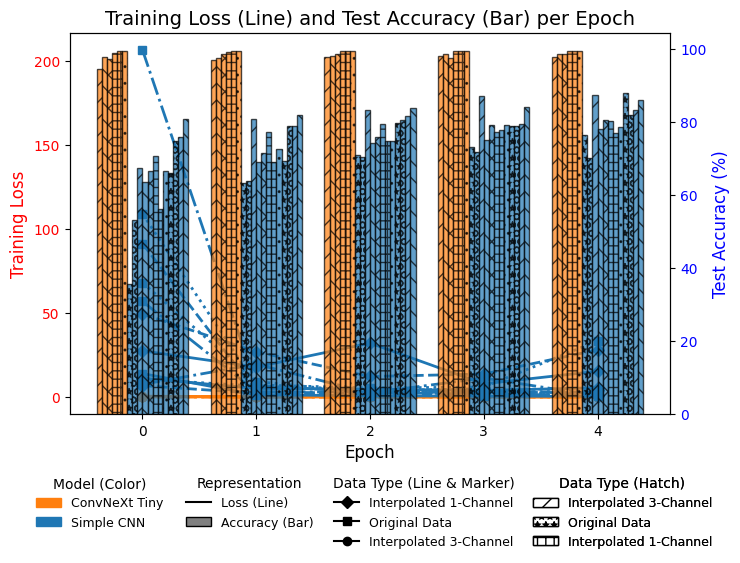

In [33]:
plot_combined_loss_and_accuracy(feature_fused_results, dir=RESULTS_DIR, plot_name="feature_fused_results")

In [31]:
summary_table = [
    ["Only-Visual", r['data_type'], r['name'], r['train_acc_final'], r['test_acc_final'], r['training_time']] for r in visual_results
] + [
    ["Only-Audio", r['data_type'], r['name'], r['train_acc_final'], r['test_acc_final'], r['training_time']] for r in audio_results
] + [
    [r['fused_method'], r['data_type'], r['name'], r['train_acc_final'], r['test_acc_final'], r['training_time']] for r in feature_fused_results
]
print(tabulate(summary_table, headers=["Modality", "Data Type", "Model", "Train Accuracy", "Test Accuracy", "Training Time"], tablefmt="github"))

| Modality          | Data Type              | Model         | Train Accuracy   | Test Accuracy   | Training Time   |
|-------------------|------------------------|---------------|------------------|-----------------|-----------------|
| Only-Visual       | Original Data          | Simple CNN    | 79.01%           | 74.71%          | 13.39s          |
| Only-Visual       | Interpolated 1-Channel | Simple CNN    | 88.64%           | 80.20%          | 43.16s          |
| Only-Visual       | Interpolated 3-Channel | ConvNeXt Tiny | 97.59%           | 88.85%          | 123.13s         |
| Only-Audio        | Original Data          | Simple CNN    | 59.64%           | 50.25%          | 64.67s          |
| Only-Audio        | Interpolated 1-Channel | Simple CNN    | 52.59%           | 46.25%          | 42.49s          |
| Only-Audio        | Interpolated 3-Channel | ConvNeXt Tiny | 94.40%           | 81.84%          | 122.88s         |
| Fused-Concat      | Interpolated 3-Channel | ConvNeXt 

<h3 style='color:#2e6c80;margin-bottom:8px'>Problem 1f: Alternative Fusion Strategy (Score Fusion) </h3>
<div style='font-size:14px;line-height:1.4;margin-bottom:10px'>Use a different fusion strategy and compare its performance with the one in 1e.</div>
<ul style='margin-top:0px;margin-bottom:10px;padding-left:20px;font-size:13px;'>
<li>Which fusion strategy works better and why?</li>
</ul>

In [24]:
# ------------------- Imports -------------------
import time
import torch
import torch.nn as nn
import torch.optim as optim
import torchaudio.transforms as T
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from tqdm import tqdm
from tabulate import tabulate
import timm
import numpy as np

# ------------------- Configuration -------------------
DATA_DIR = "data"
BATCH_SIZE = 64
NUM_EPOCHS = 5
LEARNING_RATE = 1e-5
NUM_CLASSES = 10
ORIG_SAMPLE_RATE = 8000
TARGET_SAMPLE_RATE = 16000
AUDIO_WEIGHT = 0.5
VISUAL_WEIGHT = 0.5
MODELS = {
    "ConvNeXt Tiny": "convnext_tiny",
    "Simple CNN": "simpleCNN",
}
DATA_TYPES = {
    "Original Data": "original",
    "Interpolated 1-Channel": "interpolated_1-channel",
    "Interpolated 3-Channel": "interpolated_3-channel" # Not used in this practice
}
FUSED_METHODS = {
    "Fixed Weights": 'fixed_weights',
    "Dynamic Weights": 'dynamic_weights',
}
# ------------------- Device -------------------
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")
# ------------------- Data Handling Functions -------------------
def batched_resize(x, size=224, batch_size=64):
    resized = []
    for i in range(0, x.size(0), batch_size):
        batch = x[i:i+batch_size]
        resized_batch = F.interpolate(batch, size=(size, size), mode='bilinear', align_corners=False)
        resized.append(resized_batch)
    return torch.cat(resized, dim=0)

def resize(x, size=224):
    return F.interpolate(x, size=(size, size), mode='bilinear', align_corners=False)

def repeat(x):
    return x.repeat(1, 3, 1, 1)

def transform_mel(audio_data):
    mel_transform = T.MelSpectrogram(sample_rate=TARGET_SAMPLE_RATE, n_fft=256, hop_length=80, n_mels=32, normalized=True)
    return torch.stack([mel_transform(wf) for wf in audio_data])

def resample_audio(train_audio_data, test_audio_data):
    resampler = T.Resample(orig_freq=ORIG_SAMPLE_RATE, new_freq=TARGET_SAMPLE_RATE)
    return torch.stack([resampler(wf.float()) for wf in train_audio_data]), torch.stack([resampler(wf.float()) for wf in test_audio_data])

def load_audio(data_dir):
    train_audio_data = torch.load(f"{data_dir}/training_audio.pth")
    train_audio_labels = torch.load(f"{data_dir}/training_audio_labels.pth")
    test_audio_data = torch.load(f"{data_dir}/test_audio.pth")
    test_audio_labels = torch.load(f"{data_dir}/test_audio_labels.pth")
    train_audio_data, test_audio_data = resample_audio(train_audio_data, test_audio_data)
    return transform_mel(train_audio_data), train_audio_labels, transform_mel(test_audio_data), test_audio_labels

def load_visual(data_dir):
    return (torch.load(f"{data_dir}/training_images.pth"), torch.load(f"{data_dir}/training_images_labels.pth"),
            torch.load(f"{data_dir}/test_images.pth"), torch.load(f"{data_dir}/test_images_labels.pth"))

class AudioVisualDataset(Dataset):
    def __init__(self, visual_data, audio_data, labels):
        self.data = {'visual_data': visual_data, 'audio_data': audio_data}
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        sample = {'visual_data': self.data['visual_data'][idx], 'audio_data': self.data['audio_data'][idx]}
        label = self.labels[idx]
        return sample, label

def create_fused_dataloaders( train_visual_data, train_audio_mels, train_visual_labels,
                              test_visual_data, test_audio_mels, test_visual_labels,
                              batch_size):
    train_loader = DataLoader(AudioVisualDataset(train_visual_data, train_audio_mels, train_visual_labels), batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(AudioVisualDataset(test_visual_data, test_audio_mels, test_visual_labels), batch_size=batch_size, shuffle=False)
    return train_loader, test_loader

# ------------------- Models ---------------------
class preTrainedCNNModel(nn.Module):
    """Pre-trained CNN model using timm library."""
    def __init__(self, model_name, num_classes):
        super().__init__()
        self.model = timm.create_model(model_name, pretrained=True, num_classes=num_classes)

    def forward(self, x):
        return self.model(x)

class simpleCNN(nn.Module):
    def __init__(self):
        super(simpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        #self.fc = nn.LazyLinear(NUM_CLASSES)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2)
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)
        return x.view(x.size(0), -1)


class ScoreFusionModel(nn.Module):
    def __init__(self, audio_model, visual_model, fused_methods='fixed_weights', audio_weight=0.5, visual_weight=0.5, fused_dim=4096):
        super(ScoreFusionModel, self).__init__()
        self.audio_weight       = audio_weight
        self.visual_weight      = visual_weight
        self.fused_methods      = fused_methods
        self.audio_encoder      = audio_model
        self.visual_encoder     = visual_model
        self.audio_proj_layer   = nn.Sequential(nn.LazyLinear(fused_dim), nn.ReLU())
        self.visual_proj_layer  = nn.Sequential(nn.LazyLinear(fused_dim), nn.ReLU())
        self.audio_classifier_layer   = nn.Sequential(nn.LazyLinear(NUM_CLASSES), nn.Softmax(dim=1))
        self.visual_classifier_layer  = nn.Sequential(nn.LazyLinear(NUM_CLASSES), nn.Softmax(dim=1))
        self.modality_weights   = nn.Parameter(torch.ones(2)) if fused_methods == 'dynamic_weights' else None
        
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        audio_features  = self.audio_encoder(x['audio_data'])
        visual_features = self.visual_encoder(x['visual_data'])
        audio_encoded   = self.audio_proj_layer(audio_features)
        visual_encoded  = self.visual_proj_layer(visual_features)
        audio_classified_probs  = self.audio_classifier_layer(audio_encoded)
        visual_classified_probs = self.visual_classifier_layer(visual_encoded)
        # Fused methods
        if self.fused_methods == 'fixed_weights':
            return self.audio_weight * audio_classified_probs + self.visual_weight * visual_classified_probs
        elif self.fused_methods == 'dynamic_weights':
            weights = F.softmax(self.modality_weights, dim=0)  # shape [2]
            return weights[0] * audio_classified_probs + weights[1] * visual_classified_probs
        else:
            raise ValueError(f"Unknown fusion method '{self.fused_methods}'")

# ------------------- Training and Evaluation -------------------
def train_and_evaluate(model, train_loader, test_loader, infor, num_epochs, learning_rate):
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    train_losses, test_accuracies = [], []

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        progress_bar = tqdm(train_loader, leave=False, desc=f"{infor['model_name']}-{infor['data_type']}-{infor['fusion_method']} Epoch {epoch+1}")
        for x, y in progress_bar:
            x, y = {k: v.to(device) for k, v in x.items()}, y.to(device)
            outputs = model(x)
            loss = criterion(outputs, y)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            avg_loss = total_loss / (progress_bar.n + 1)
            progress_bar.set_postfix(loss=f"{avg_loss:.4f}")
        train_losses.append(total_loss / len(train_loader))
        test_accuracies.append(evaluate(model, test_loader))
    train_accuracy = evaluate(model, train_loader)
    return train_accuracy, train_losses, test_accuracies

def evaluate(model, data_loader):
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for x, y in data_loader:
            x, y = {k: v.to(device) for k, v in x.items()}, y.to(device)
            outputs = model(x)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == y).sum().item()
            total += y.size(0)
    return 100 * correct / total

# ------------------- Main Experiment Runner -------------------
def run_experiments():
    train_visual_data, train_visual_labels, test_visual_data, test_visual_labels = load_visual(DATA_DIR)
    train_audio_mels, train_audio_labels, test_audio_mels, test_audio_labels     = load_audio(DATA_DIR)
    train_visual_1channel, test_visual_1channel = batched_resize(train_visual_data, BATCH_SIZE), batched_resize(test_visual_data, BATCH_SIZE)
    train_audio_1channel,  test_audio_1channel  = batched_resize(train_audio_mels, BATCH_SIZE), batched_resize(test_audio_mels, BATCH_SIZE)
    train_visual_3channel, test_visual_3channel = repeat(train_visual_1channel), repeat(test_visual_1channel)
    train_audio_3channel,  test_audio_3channel  = repeat(train_audio_1channel), repeat(test_audio_1channel)
    train_loader_origin, test_loader_origin = create_fused_dataloaders(
                    train_visual_data, train_audio_mels, train_visual_labels,
                    test_visual_data, test_audio_mels, test_visual_labels,
                    BATCH_SIZE
                )
    train_loader_1channel, test_loader_1channel = create_fused_dataloaders(
                    train_visual_1channel, train_audio_1channel, train_visual_labels,
                    test_visual_1channel, test_audio_1channel, test_visual_labels,
                    BATCH_SIZE
                )
    train_loader_3channel, test_loader_3channel = create_fused_dataloaders(
                    train_visual_3channel, train_audio_3channel, train_visual_labels,
                    test_visual_3channel, test_audio_3channel, test_visual_labels,
                    BATCH_SIZE
                )
    print(f"Train Visual Origin:         {train_visual_data.shape},     Labels: {train_visual_labels.shape}")
    print(f"Test  Visual Origin:         {test_visual_data.shape},      Labels: {test_visual_labels.shape}")
    print(f"Train Visual 1-Channel:      {train_visual_1channel.shape}, Labels: {train_visual_labels.shape}")
    print(f"Test  Visual 1-Channel:      {test_visual_1channel.shape},  Labels: {test_visual_labels.shape}")
    print(f"Train Audio Melspectrograms: {train_audio_mels.shape},      Labels: {train_audio_labels.shape}")
    print(f"Test Audio Melspectrograms:  {test_audio_mels.shape},       Labels: {test_audio_labels.shape}")

    results = []
    prj_dim = 4096
    for data_name, data_type in DATA_TYPES.items():
        for model_name, model in MODELS.items():
            if (model == "simpleCNN" and data_type == "interpolated_3-channel") or (model != "simpleCNN" and data_type != "interpolated_3-channel"):
                continue
            audio_encoder = simpleCNN()  if model_name == "Simple CNN" else preTrainedCNNModel(model, prj_dim)
            visual_encoder = simpleCNN() if model_name == "Simple CNN" else preTrainedCNNModel(model, prj_dim)
            train_loader = train_loader_origin if data_type == "original" else (
                train_loader_1channel if data_type == "interpolated_1-channel" else train_loader_3channel)
            test_loader = test_loader_origin if data_type == "original" else (
                test_loader_1channel if data_type == "interpolated_1-channel" else test_loader_3channel)
            for fused_name, fused_method in FUSED_METHODS.items():
                info = {'model_name': model_name, 'data_type': data_type, 'fusion_method': fused_name}
                model = ScoreFusionModel(audio_model=audio_encoder, visual_model=visual_encoder, fused_methods=fused_method, audio_weight=AUDIO_WEIGHT, visual_weight=VISUAL_WEIGHT)
                model.to(device)
                start_time = time.time()
                train_acc, train_losses, test_accs = train_and_evaluate(model, train_loader, test_loader, info, NUM_EPOCHS, LEARNING_RATE)
                elapsed = time.time() - start_time
                results.append({
                    'name': model_name,
                    'fused_method': fused_name,
                    'data_type': data_name,
                    'train_loss': train_losses,
                    'test_accuracy': test_accs,
                    'train_acc_final': f"{train_acc:.2f}%",
                    'test_acc_final': f"{test_accs[-1]:.2f}%",
                    'training_time': f"{elapsed:.2f}s"
                })
    return results

# ------------------- Entry Point -------------------
if __name__ == "__main__":
    score_fused_results = run_experiments()

    print("\nScore Fused Model Results:")
    print(tabulate([[r['fused_method'], r['data_type'], r['name'], r['train_acc_final'], r['test_acc_final'], r['training_time']] for r in score_fused_results],
                   headers=["Modality", "Data Type", "Model", "Train Accuracy", "Test Accuracy", "Training Time"], tablefmt="github"))

Using device: mps
Train Visual Origin:         torch.Size([17560, 1, 28, 28]),     Labels: torch.Size([17560])
Test  Visual Origin:         torch.Size([5859, 1, 28, 28]),      Labels: torch.Size([5859])
Train Visual 1-Channel:      torch.Size([17560, 1, 64, 64]), Labels: torch.Size([17560])
Test  Visual 1-Channel:      torch.Size([5859, 1, 64, 64]),  Labels: torch.Size([5859])
Train Audio Melspectrograms: torch.Size([17560, 1, 32, 201]),      Labels: torch.Size([17560])
Test Audio Melspectrograms:  torch.Size([5859, 1, 32, 201]),       Labels: torch.Size([5859])



Score Fused Model Results:
| Modality        | Data Type              | Model         | Train Accuracy   | Test Accuracy   | Training Time   |
|-----------------|------------------------|---------------|------------------|-----------------|-----------------|
| Fixed Weights   | Original Data          | Simple CNN    | 71.10%           | 65.90%          | 76.69s          |
| Dynamic Weights | Original Data          | Simple CNN    | 74.40%           | 68.65%          | 75.19s          |
| Fixed Weights   | Interpolated 1-Channel | Simple CNN    | 70.24%           | 66.39%          | 83.25s          |
| Dynamic Weights | Interpolated 1-Channel | Simple CNN    | 83.12%           | 78.56%          | 84.18s          |
| Fixed Weights   | Interpolated 3-Channel | ConvNeXt Tiny | 97.94%           | 95.53%          | 308.51s         |
| Dynamic Weights | Interpolated 3-Channel | ConvNeXt Tiny | 96.77%           | 93.41%          | 297.37s         |


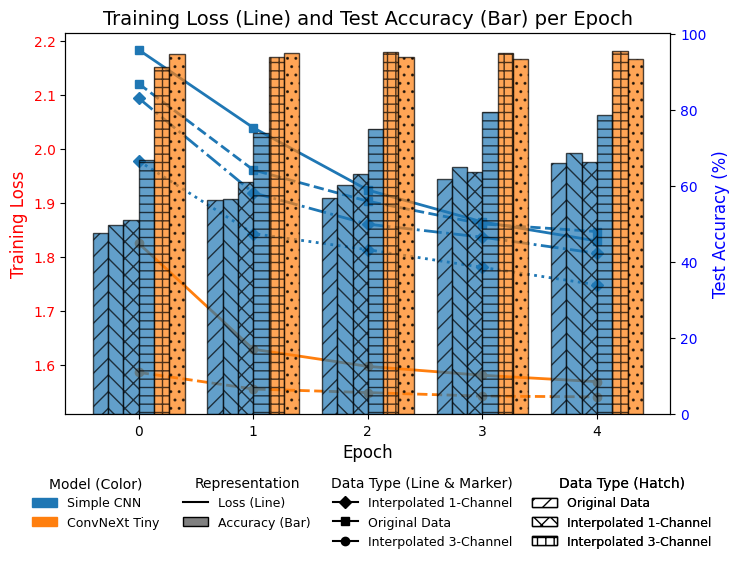

In [34]:
plot_combined_loss_and_accuracy(score_fused_results, dir=RESULTS_DIR, plot_name="score_fused_results")

In [43]:
from tabulate import tabulate
RESULTS_ACC_DIR = "NLDL_FYS-8604/acc_results"
summary_table = [
    ["Only-Visual", r['data_type'], r['name'], r['train_acc_final'], r['test_acc_final'], r['training_time']] for r in visual_results
] + [
    ["Only-Audio", r['data_type'], r['name'], r['train_acc_final'], r['test_acc_final'], r['training_time']] for r in audio_results
] + [
    [r['fused_method'], r['data_type'], r['name'], r['train_acc_final'], r['test_acc_final'], r['training_time']] for r in feature_fused_results
] + [
    [r['fused_method'], r['data_type'], r['name'], r['train_acc_final'], r['test_acc_final'], r['training_time']] for r in score_fused_results
]

print(tabulate(summary_table, headers=["Modality", "Data Type", "Model", "Train Accuracy", "Test Accuracy", "Training Time"], tablefmt="github"))

visual_table = tabulate(
    [["Visual", r['data_type'], r['name'], r['train_acc_final'], r['test_acc_final'], r['training_time']] for r in visual_results],
    headers=["Modality", "Data Type", "Model", "Train Acc", "Test Acc", "Training Time"],
    tablefmt="latex_booktabs"
)
# Wrap it in your LaTeX table environment
visual_full_latex = f"""\\begin{{table}}[tb]
    \\centering
    \\caption{{Result of Visual-based Classifiers in terms of accuracy (\\%).}}
    \\label{{tab:visual_results}}
    \\resizebox{{\\linewidth}}{{!}}{{%
        {visual_table}
    }}
\\end{{table}}"""
visual_full_latex = visual_full_latex.replace(r"\begin{tabular}{llllll}", r"\begin{tabular}{lccccc}")

with open(f"{RESULTS_ACC_DIR}/visual_results_table.tex", "w") as f:
    f.write(visual_full_latex)

audio_table = tabulate(
    [["Audio", r['data_type'], r['name'], r['train_acc_final'], r['test_acc_final'], r['training_time']] for r in audio_results],
    headers=["Modality", "Data Type", "Model", "Train Acc", "Test Acc", "Training Time"],
    tablefmt="latex_booktabs"
)
audio_full_latex = f"""\\begin{{table}}[tb]
    \\centering
    \\caption{{Result of Audio-based Classifiers in terms of accuracy (\\%).}}
    \\label{{tab:audio_results}}
    \\resizebox{{\\linewidth}}{{!}}{{%
        {audio_table}
    }}
\\end{{table}}"""
audio_full_latex = audio_full_latex.replace(r"\begin{tabular}{llllll}", r"\begin{tabular}{lccccc}")
with open(f"{RESULTS_ACC_DIR}/audio_results_table.tex", "w") as f:
    f.write(audio_full_latex)

visualaudio_table = tabulate(
    [["Visual", r['data_type'], r['name'], r['train_acc_final'], r['test_acc_final'], r['training_time']] for r in visual_results] +
    [["Audio", r['data_type'], r['name'], r['train_acc_final'], r['test_acc_final'], r['training_time']] for r in audio_results],
    headers=["Modality", "Data Type", "Model", "Train Acc", "Test Acc", "Training Time"],
    tablefmt="latex_booktabs"
)
visualaudio_full_latex = f"""\\begin{{table}}[tb]
    \\centering
    \\caption{{Result of Uni-modality Classifiers in terms of accuracy (\\%).}}
    \\label{{tab:unimodal_results}}
    \\resizebox{{\\linewidth}}{{!}}{{%
        {visualaudio_table}
    }}
\\end{{table}}"""
visualaudio_full_latex = visualaudio_full_latex.replace(r"\begin{tabular}{llllll}", r"\begin{tabular}{lccccc}")
with open(f"{RESULTS_ACC_DIR}/visual_audio_results_table.tex", "w") as f:
    f.write(visualaudio_full_latex)

feature_table = tabulate(
    [[r['fused_method'], r['data_type'], r['name'], r['train_acc_final'], r['test_acc_final'], r['training_time']] for r in feature_fused_results],
    headers=["Modality", "Data Type", "Model", "Train Acc", "Test Acc", "Training Time"],
    tablefmt="latex_booktabs"
)
feature_full_latex = f"""\\begin{{table}}[tb]
    \\centering
    \\caption{{Result of Feature Fusion-based Classifiers in terms of accuracy (\\%).}}
    \\label{{tab:feature_fusion_results}}
    \\resizebox{{\\linewidth}}{{!}}{{%
        {feature_table}
    }}
\\end{{table}}"""
feature_full_latex = feature_full_latex.replace(r"\begin{tabular}{llllll}", r"\begin{tabular}{lccccc}")
with open(f"{RESULTS_ACC_DIR}/feature_fusion_results_table.tex", "w") as f:
    f.write(feature_full_latex)

score_table = tabulate(
    [[r['fused_method'], r['data_type'], r['name'], r['train_acc_final'], r['test_acc_final'], r['training_time']] for r in score_fused_results],
    headers=["Modality", "Data Type", "Model", "Train Acc", "Test Acc", "Training Time"],
    tablefmt="latex_booktabs"
)
score_full_latex = f"""\\begin{{table}}[tb]
    \\centering
    \\caption{{Result of Score Fusion-based Classifiers in terms of accuracy (\\%).}}
    \\label{{tab:score_fusion_results}}
    \\resizebox{{\\linewidth}}{{!}}{{%
        {score_table}
    }}
\\end{{table}}"""
score_full_latex = score_full_latex.replace(r"\begin{tabular}{llllll}", r"\begin{tabular}{lccccc}")
with open(f"{RESULTS_ACC_DIR}/score_fusion_results_table.tex", "w") as f:
    f.write(score_full_latex)


| Modality          | Data Type              | Model         | Train Accuracy   | Test Accuracy   | Training Time   |
|-------------------|------------------------|---------------|------------------|-----------------|-----------------|
| Only-Visual       | Original Data          | Simple CNN    | 79.01%           | 74.71%          | 13.39s          |
| Only-Visual       | Interpolated 1-Channel | Simple CNN    | 88.64%           | 80.20%          | 43.16s          |
| Only-Visual       | Interpolated 3-Channel | ConvNeXt Tiny | 97.59%           | 88.85%          | 123.13s         |
| Only-Audio        | Original Data          | Simple CNN    | 59.64%           | 50.25%          | 64.67s          |
| Only-Audio        | Interpolated 1-Channel | Simple CNN    | 52.59%           | 46.25%          | 42.49s          |
| Only-Audio        | Interpolated 3-Channel | ConvNeXt Tiny | 94.40%           | 81.84%          | 122.88s         |
| Fused-Concat      | Interpolated 3-Channel | ConvNeXt 

<h3 style='color:#2e6c80;margin-bottom:8px'>Problem 1g: Representation Visualization</h3>
<div style='font-size:14px;line-height:1.4;margin-bottom:10px'>Visualize the model’s internal representations before and after fusion.</div>
<ul style='margin-top:0px;margin-bottom:10px;padding-left:20px;font-size:13px;'>
<li>Use PCA or t-SNE for dimensionality reduction.</li>
<li>Discuss clustering and class separation.</li>
</ul>

Using device: mps
Train Visual Origin:         torch.Size([17560, 1, 28, 28]),     Labels: torch.Size([17560])
Test  Visual Origin:         torch.Size([5859, 1, 28, 28]),      Labels: torch.Size([5859])
Train Visual 1-Channel:      torch.Size([17560, 1, 64, 64]), Labels: torch.Size([17560])
Test  Visual 1-Channel:      torch.Size([5859, 1, 64, 64]),  Labels: torch.Size([5859])
Train Visual 3-Channel:      torch.Size([17560, 3, 64, 64]), Labels: torch.Size([17560])
Test  Visual 3-Channel:      torch.Size([5859, 3, 64, 64]),  Labels: torch.Size([5859])
Train Audio Melspectrograms: torch.Size([17560, 1, 32, 201]),      Labels: torch.Size([17560])
Test Audio Melspectrograms:  torch.Size([5859, 1, 32, 201]),       Labels: torch.Size([5859])
Running Simple CNN on Original Data with fusion method Fused-Multiply


Running Simple CNN on Original Data with fusion method Fused-WeightedSum


Running Simple CNN on Original Data with fusion method Fused-Gated


Running Simple CNN on Interpolated 1-Channel with fusion method Fused-Multiply


Running Simple CNN on Interpolated 1-Channel with fusion method Fused-WeightedSum


Running Simple CNN on Interpolated 1-Channel with fusion method Fused-Gated



Feature Fused Model Results:
| Modality          | Data Type              | Model      | Train Accuracy   | Test Accuracy   | Training Time   |
|-------------------|------------------------|------------|------------------|-----------------|-----------------|
| Fused-Multiply    | Original Data          | Simple CNN | 88.41%           | 81.81%          | 78.49s          |
| Fused-WeightedSum | Original Data          | Simple CNN | 84.36%           | 75.76%          | 72.87s          |
| Fused-Gated       | Original Data          | Simple CNN | 75.87%           | 71.22%          | 91.81s          |
| Fused-Multiply    | Interpolated 1-Channel | Simple CNN | 93.28%           | 87.97%          | 91.28s          |
| Fused-WeightedSum | Interpolated 1-Channel | Simple CNN | 83.70%           | 78.75%          | 97.83s          |
| Fused-Gated       | Interpolated 1-Channel | Simple CNN | 88.10%           | 81.12%          | 112.76s         |


/var/folders/_g/75yf12m17c72dlv2_y5qtp3c0000gp/T/ipykernel_27203/76788359.py:404: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(right=0.9)


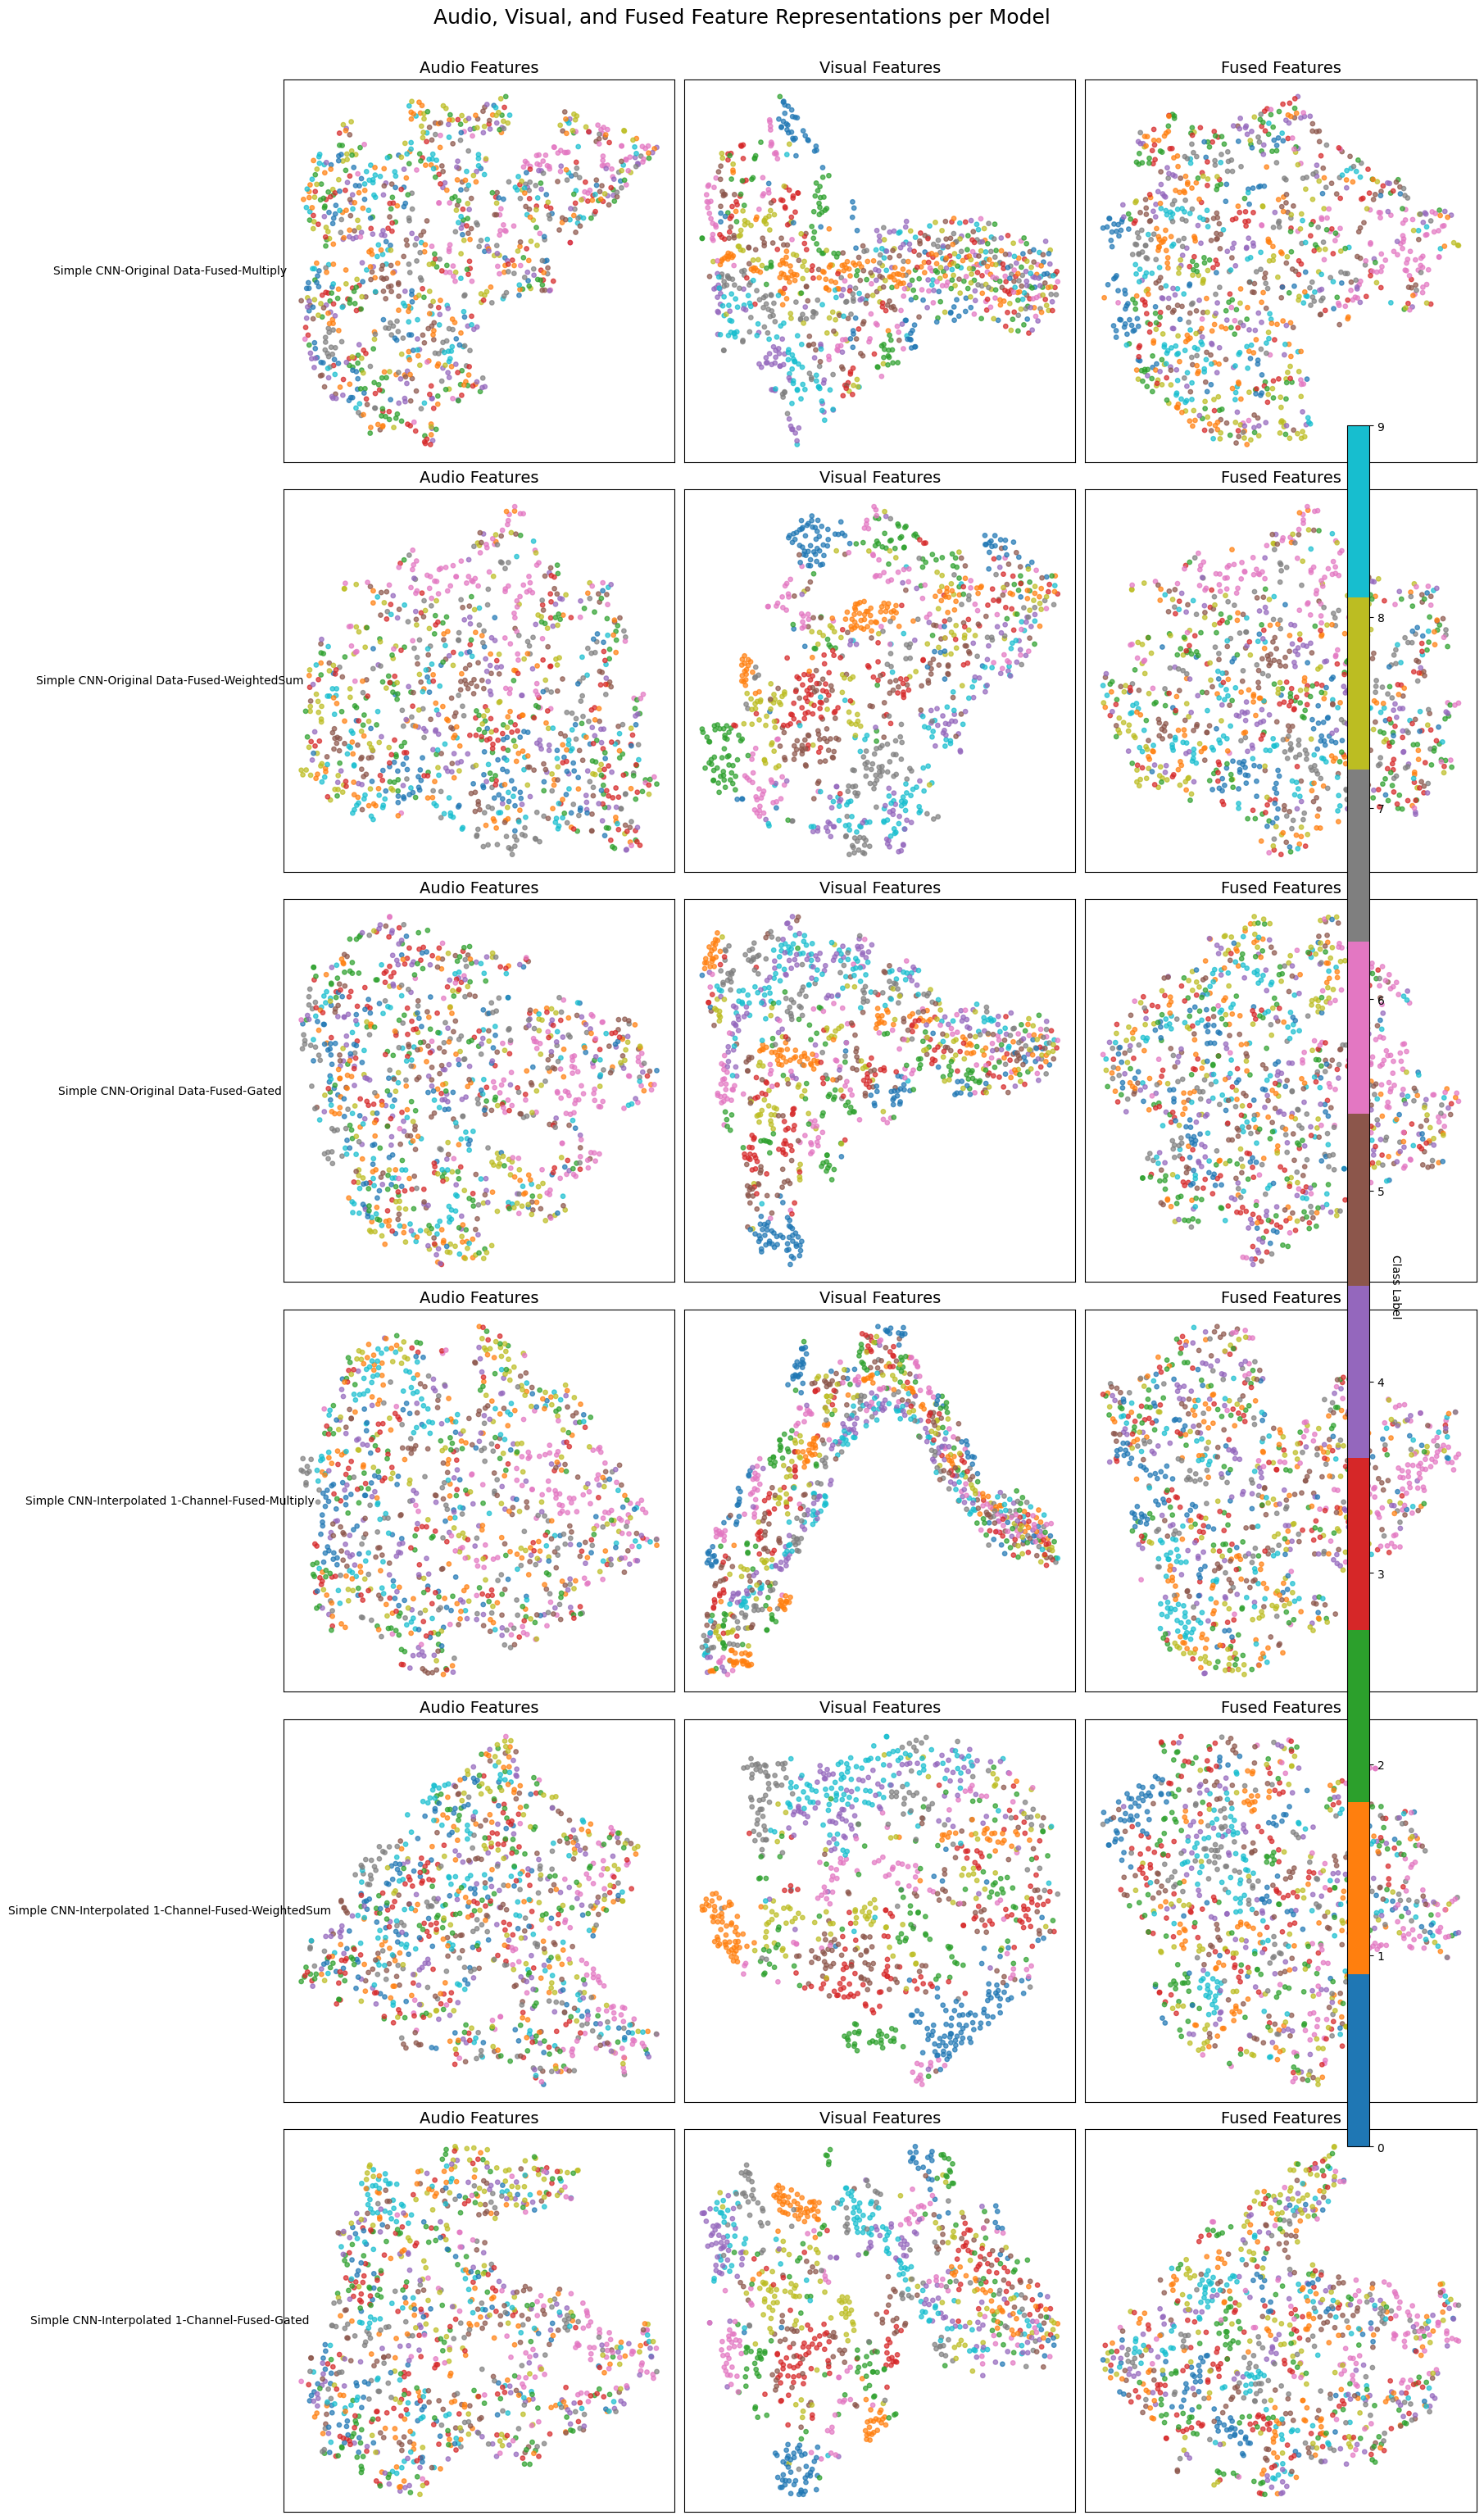

In [ ]:
import time
import torch
import torch.nn as nn
import torch.optim as optim
import torchaudio.transforms as T
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset
import matplotlib.pyplot as plt
from tqdm import tqdm
from tabulate import tabulate
import timm

# ------------------- Configuration -------------------
DATA_DIR = "data"
BATCH_SIZE = 64
NUM_EPOCHS = 5
LEARNING_RATE = 1e-5
NUM_CLASSES = 10
ORIG_SAMPLE_RATE = 8000
TARGET_SAMPLE_RATE = 16000
MODELS = {
    #"ConvNeXt Tiny": "convnext_tiny",
    "Simple CNN": "simpleCNN",
}
FUSED_METHODS = {
    #"Fused-Concat": 'concat',
    #"Fused-Add": "sum",
    "Fused-Multiply": "multiply",
    #"Fused-Average": "average",
    "Fused-WeightedSum": "weighted_sum",
    "Fused-Gated": "gated"
}
DATA_TYPES = {
    #"Interpolated 3-Channel": "interpolated_3-channel",
    "Original Data": "original",
    "Interpolated 1-Channel": "interpolated_1-channel",
}
RESULTS_DIR = "NLDL_FYS-8604/images"
# ------------------- Device -------------------
device = torch.device("cuda" if torch.cuda.is_available()
                      else "mps" if torch.backends.mps.is_available()
                      else "cpu")
print(f"Using device: {device}")
# ------------------- Data Handling Functions -------------------
def batched_resize(x, size=224, batch_size=64):
    resized = []
    for i in range(0, x.size(0), batch_size):
        batch = x[i:i+batch_size]
        resized_batch = F.interpolate(batch, size=(size, size), mode='bilinear', align_corners=False)
        resized.append(resized_batch)
    return torch.cat(resized, dim=0)

def resize(x, size=224):
    """Resize images to the specified size."""
    return F.interpolate(x, size=(size, size), mode='bilinear', align_corners=False)

def repeat(x): # for pre-trained models
    """Repeat the input tensor to match the expected input shape for pre-trained models."""
    return x.repeat(1, 3, 1, 1)

def transform_mel(audio_data):
    mel_transform = T.MelSpectrogram(
        sample_rate=TARGET_SAMPLE_RATE,
        n_fft=256,
        hop_length=80,
        n_mels=32,
        normalized=True
    )
    mel_spectrograms = torch.stack([mel_transform(wf) for wf in audio_data])
    return mel_spectrograms

def resample_audio(train_audio_data, test_audio_data):
    resampler = T.Resample(orig_freq=ORIG_SAMPLE_RATE, new_freq=TARGET_SAMPLE_RATE)
    train_audio_resampled = torch.stack([resampler(wf.float()) for wf in train_audio_data])
    test_audio_resampled = torch.stack([resampler(wf.float()) for wf in test_audio_data])
    return train_audio_resampled, test_audio_resampled

def load_audio(data_dir): # from 8000 to 16000 Hz
    train_audio_data   = torch.load(f"{data_dir}/training_audio.pth")
    train_audio_labels = torch.load(f"{data_dir}/training_audio_labels.pth")
    test_audio_data    = torch.load(f"{data_dir}/test_audio.pth")
    test_audio_labels  = torch.load(f"{data_dir}/test_audio_labels.pth")
    train_audio_data, test_audio_data = resample_audio(train_audio_data, test_audio_data)
    train_audio_mels, test_audio_mels = transform_mel(train_audio_data), transform_mel(test_audio_data)
    return train_audio_mels, train_audio_labels, test_audio_mels, test_audio_labels

def load_visual(data_dir):
    train_visual_data = torch.load(f"{data_dir}/training_images.pth")
    train_visual_labels = torch.load(f"{data_dir}/training_images_labels.pth")
    test_visual_data = torch.load(f"{data_dir}/test_images.pth")
    test_visual_labels = torch.load(f"{data_dir}/test_images_labels.pth")
    return train_visual_data, train_visual_labels, test_visual_data, test_visual_labels

class AudioVisualDataset(Dataset):
    def __init__(self, visual_data, audio_data, labels):
        self.data = {'visual_data': visual_data, 'audio_data': audio_data}
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        sample = {'visual_data': self.data['visual_data'][idx], 'audio_data': self.data['audio_data'][idx]}
        label = self.labels[idx]
        return sample, label
    
def create_fused_dataloaders(train_visual_data, train_audio_mels, train_labels,
                       test_visual_data, test_audio_mels, test_labels,
                       batch_size):
    train_dataset     = AudioVisualDataset(train_visual_data, train_audio_mels, train_labels)
    test_dataset      = AudioVisualDataset(test_visual_data, test_audio_mels, test_labels)
    train_loader      = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader       = DataLoader(test_dataset, batch_size=batch_size, shuffle=True)
    return train_loader, test_loader

# ------------------- Models ---------------------
class preTrainedCNNModel(nn.Module):
    def __init__(self, model_name, num_classes=10):
        super().__init__()
        self.model = timm.create_model(model_name, pretrained=True, num_classes=num_classes)

    def forward(self, x):
        return self.model(x)
    
class simpleCNN(nn.Module):
    """Simple CNN Encoder from the 1st practice in the course """
    def __init__(self):
        super(simpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        #self.fc1 = nn.LazyLinear(num_classes)  # move to FusedModel

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Input shape:    [batch_size, 1, W, H]
        Output shape:   [batch_size, 64 * W/4 * H/4]
        Example of Visual:          [64, 1, 28, 28]  -> [64, 64 * 7 * 7]  = [64, 3136]
        Example of Melspectrogram:  [64, 1, 32, 201] -> [64, 64 * 8 * 50] = [64, 25600]
        """
        x = F.relu(self.conv1(x))   # [batch_size, 32, W, H]
        x = F.max_pool2d(x, 2)      # [batch_size, 32, W/2, H/2]
        x = F.relu(self.conv2(x))   # [batch_size, 64, W/2, H/2]
        x = F.max_pool2d(x, 2)      # [batch_size, 64, W/4, H/4]
        x = x.view(x.size(0), -1)   # Flatten: [batch_size, 64 * W/4 * H/4] 
        #x = self.fc1(x) # move to FusedModel
        return x

class FusedModel(nn.Module):
    def __init__(self, audio_model, 
                 visual_model, num_classes=10, fusion_method='concat',
                 fusion_alpha=0.5, fused_dim=4096):
        """
        Combines audio and visual features using a flexible fusion strategy.
        Supported methods: concat, sum, multiply, average, weighted_sum, gated
        """
        super(FusedModel, self).__init__()
        self.audio_model   = audio_model
        self.visual_model  = visual_model
        self.fusion_method = fusion_method
        self.audio_proj  = nn.Sequential(nn.LazyLinear(fused_dim), nn.ReLU())
        self.visual_proj = nn.Sequential(nn.LazyLinear(fused_dim), nn.ReLU())
        self.gate_layer  = nn.Sequential(nn.LazyLinear(fused_dim), nn.Sigmoid())
        self.alpha  = nn.Parameter(torch.tensor(fusion_alpha))
        self.fc1    = nn.LazyLinear(num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        audio, visual = x['audio_data'], x['visual_data']
        audio_out   = self.audio_proj(self.audio_model(audio))    # Project: [batch_size, prj_dim]
        visual_out  = self.visual_proj(self.visual_model(visual)) # Project: [batch_size, prj_dim]
        # Fusion logic
        if self.fusion_method == 'concat':
            fused = torch.cat((audio_out, visual_out), dim=1)
        elif self.fusion_method == 'sum':
            fused = audio_out + visual_out
        elif self.fusion_method == 'multiply':
            fused = audio_out * visual_out
        elif self.fusion_method == 'average':
            fused = (audio_out + visual_out) / 2
        elif self.fusion_method == 'weighted_sum':
            fused = self.alpha * audio_out + (1 - self.alpha) * visual_out
        elif self.fusion_method == 'gated':
            gate = self.gate_layer(torch.cat((audio_out, visual_out), dim=1))
            fused = gate * audio_out + (1 - gate) * visual_out
        else:
            raise ValueError(f"Unknown fusion method '{self.fusion_method}'")
        return self.fc1(fused)
    
# ------------------- Training and Evaluation -------------------
def train_and_evaluate(model, train_loader, test_loader, infor, num_epochs, learning_rate):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    train_losses = []
    test_accuracies = []

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        progress_bar = tqdm(train_loader, leave=False, desc=f"{infor['model_name']}-{infor['data_type']}-{infor['fusion_method']} Epoch {epoch+1}")
        for x, y in progress_bar:
            x, y = {k: v.to(device) for k, v in x.items()}, y.to(device)
            outputs = model(x)
            loss = criterion(outputs, y)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            avg_loss = total_loss / (progress_bar.n + 1)
            progress_bar.set_postfix(loss=f"{avg_loss:.4f}")  
        train_losses.append(total_loss / len(train_loader))
        test_accuracy = evaluate(model, test_loader)
        test_accuracies.append(test_accuracy)
    train_accuracy = evaluate(model, train_loader)
    return train_accuracy, train_losses, test_accuracies

def evaluate(model, test_loader):
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for x, y in test_loader:
            x, y = {k: v.to(device) for k, v in x.items()}, y.to(device)
            outputs = model(x)
            _, preds = torch.max(outputs, 1)
            correct += (preds == y).sum().item()
            total += y.size(0)
    accuracy = 100 * correct / total
    return accuracy

# ------------------- Visualization Functions -------------------
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import matplotlib.gridspec as gridspec

def visualize_representations(model, data_loader, title_suffix="", method="tsne", num_samples=500):
    model.eval()
    audio_feats, visual_feats, fused_feats, labels = [], [], [], []

    with torch.no_grad():
        for x, y in data_loader:
            x = {k: v.to(device) for k, v in x.items()}
            y = y.to(device)

            audio, visual = x['audio_data'], x['visual_data']
            audio_out   = model.audio_proj(model.audio_model(audio))    # Project: [batch_size, prj_dim]
            visual_out  = model.visual_proj(model.visual_model(visual)) # Project: [batch_size, prj_dim]
            # Fusion logic
            if model.fusion_method == 'concat':
                fused = torch.cat((audio_out, visual_out), dim=1)
            elif model.fusion_method == 'sum':
                fused = audio_out + visual_out
            elif model.fusion_method == 'multiply':
                fused = audio_out * visual_out
            elif model.fusion_method == 'average':
                fused = (audio_out + visual_out) / 2
            elif model.fusion_method == 'weighted_sum':
                fused = model.alpha * audio_out + (1 - model.alpha) * visual_out
            elif model.fusion_method == 'gated':
                gate = model.gate_layer(torch.cat((audio_out, visual_out), dim=1))
                fused = gate * audio_out + (1 - gate) * visual_out
            else:
                raise ValueError(f"Unknown fusion method '{model.fusion_method}'")

            audio_feats.append(audio_out.cpu())
            visual_feats.append(visual_out.cpu())
            fused_feats.append(fused.cpu())
            labels.append(y.cpu())

            if len(labels) * x['audio_data'].size(0) >= num_samples:
                break

    audio_feats  = torch.cat(audio_feats)[:num_samples]
    visual_feats = torch.cat(visual_feats)[:num_samples]
    fused_feats  = torch.cat(fused_feats)[:num_samples]
    labels       = torch.cat(labels)[:num_samples]

    reducer   = TSNE(n_components=2, random_state=42) if method == "tsne" else PCA(n_components=2)
    audio_2d  = reducer.fit_transform(audio_feats)
    visual_2d = reducer.fit_transform(visual_feats)
    fused_2d  = reducer.fit_transform(fused_feats)

    # --- Plotting utilities ---
    def plot_trio(data_list, labels, titles, suptitle, class_names=None):
        fig = plt.figure(figsize=(20, 6))
        gs = gridspec.GridSpec(1, 4, width_ratios=[1, 1, 1, 0.05])  # 3 plots + 1 for colorbar

        axes = [fig.add_subplot(gs[i]) for i in range(3)]
        scatter = None

        for ax, data, title in zip(axes, data_list, titles):
            scatter = ax.scatter(data[:, 0], data[:, 1], c=labels, cmap='tab10', alpha=0.7)
            ax.set_title(title)

        # Shared colorbar on the 4th column
        cbar_ax = fig.add_subplot(gs[3])
        cbar = fig.colorbar(scatter, cax=cbar_ax)

        # Use custom class names if provided
        if class_names:
            ticks = list(range(len(class_names)))
            cbar.set_ticks(ticks)
            cbar.set_ticklabels(class_names)
            cbar_ax.set_ylabel("Class", rotation=270, labelpad=15)

        fig.suptitle(suptitle, fontsize=16)
        fig.subplots_adjust(wspace=0.3)
        plt.show()


    # --- Plot all ---
    plot_trio(
        [audio_2d, visual_2d, fused_2d],
        labels,
        ["Audio Features", "Visual Features", "Fused Features"],
        f"Feature Representations {title_suffix}"
    )

def visualize_representations_all_models(models_with_loaders_and_names, method="tsne", num_samples=500):
    import matplotlib.pyplot as plt
    import matplotlib.gridspec as gridspec
    from matplotlib import cm
    from matplotlib.colors import Normalize
    import numpy as np

    all_audio_2d = []
    all_visual_2d = []
    all_fused_2d = []
    all_labels = []
    all_names = []

    # Collect features
    for model, loader, name in models_with_loaders_and_names:
        model.eval()
        audio_feats, visual_feats, fused_feats, labels = [], [], [], []

        with torch.no_grad():
            for x, y in loader:
                x = {k: v.to(device) for k, v in x.items()}
                y = y.to(device)
                audio = x['audio_data']
                visual = x['visual_data']
                audio_out = model.audio_proj(model.audio_model(audio))
                visual_out = model.visual_proj(model.visual_model(visual))
                if model.fusion_method == 'concat':
                    fused = torch.cat((audio_out, visual_out), dim=1)
                elif model.fusion_method == 'sum':
                    fused = audio_out + visual_out
                elif model.fusion_method == 'multiply':
                    fused = audio_out * visual_out
                elif model.fusion_method == 'average':
                    fused = (audio_out + visual_out) / 2
                elif model.fusion_method == 'weighted_sum':
                    fused = model.alpha * audio_out + (1 - model.alpha) * visual_out
                elif model.fusion_method == 'gated':
                    gate = model.gate_layer(torch.cat((audio_out, visual_out), dim=1))
                    fused = gate * audio_out + (1 - gate) * visual_out
                else:
                    raise ValueError(f"Unknown fusion method '{model.fusion_method}'")
                audio_feats.append(audio_out.cpu())
                visual_feats.append(visual_out.cpu())
                fused_feats.append(fused.cpu())
                labels.append(y.cpu())
                if len(torch.cat(labels)) >= num_samples:
                    break

        audio_feats = torch.cat(audio_feats)[:num_samples]
        visual_feats = torch.cat(visual_feats)[:num_samples]
        fused_feats = torch.cat(fused_feats)[:num_samples]
        labels = torch.cat(labels)[:num_samples]

        reducer = TSNE(n_components=2, random_state=42) if method == "tsne" else PCA(n_components=2)
        audio_2d = reducer.fit_transform(audio_feats)
        visual_2d = reducer.fit_transform(visual_feats)
        fused_2d = reducer.fit_transform(fused_feats)

        all_audio_2d.append(audio_2d)
        all_visual_2d.append(visual_2d)
        all_fused_2d.append(fused_2d)
        all_labels.append(labels.numpy())
        all_names.append(name)

    n_models = len(all_names)
    fig = plt.figure(figsize=(16, 4 * n_models))
    outer_grid = gridspec.GridSpec(n_models, 1, wspace=0.3, hspace=0.6)

    for i in range(n_models):
        inner_grid = gridspec.GridSpecFromSubplotSpec(1, 4, subplot_spec=outer_grid[i], width_ratios=[1, 1, 1, 0.05], wspace=0.3)

        titles = ["Audio Features", "Visual Features", "Fused Features"]
        data_list = [all_audio_2d[i], all_visual_2d[i], all_fused_2d[i]]
        label_data = all_labels[i]

        for j in range(3):
            ax = plt.Subplot(fig, inner_grid[j])
            scatter = ax.scatter(data_list[j][:, 0], data_list[j][:, 1], c=label_data, cmap='tab10', s=12, alpha=0.7)
            ax.set_title(titles[j], fontsize=12)
            ax.set_xticks([])
            ax.set_yticks([])
            fig.add_subplot(ax)

        # Row title (above the 3 subplots)
        fig.text(0.5, outer_grid[i].get_position(fig).y1 + 0.02, all_names[i], ha='center', fontsize=14, fontweight='bold')

        # Colorbar to the right
        cax = plt.Subplot(fig, inner_grid[3])
        norm = Normalize(vmin=0, vmax=9)
        cb = fig.colorbar(cm.ScalarMappable(norm=norm, cmap='tab10'), cax=cax, ticks=range(10))
        cb.set_label('Class Label', fontsize=10)
        fig.add_subplot(cax)

    plt.title("", fontsize=0)
    fig.canvas.draw()
    fig.savefig(f"{RESULTS_DIR}/feature_representations_all_models.png", bbox_inches='tight', dpi=300)
    plt.suptitle("Audio, Visual, and Fused Feature Representations per Model Setup", fontsize=18, y=0.995)
    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.show()


# ------------------- Experiment Runner -------------------
def run_experiments():
    train_visual_data, train_visual_labels, test_visual_data, test_visual_labels = load_visual(DATA_DIR)
    train_audio_mels, train_audio_labels, test_audio_mels, test_audio_labels     = load_audio(DATA_DIR)
    train_visual_1channel, test_visual_1channel = batched_resize(train_visual_data, BATCH_SIZE), batched_resize(test_visual_data, BATCH_SIZE)
    train_audio_1channel,  test_audio_1channel  = batched_resize(train_audio_mels, BATCH_SIZE), batched_resize(test_audio_mels, BATCH_SIZE)
    train_visual_3channel, test_visual_3channel = repeat(train_visual_1channel), repeat(test_visual_1channel)
    train_audio_3channel,  test_audio_3channel  = repeat(train_audio_1channel), repeat(test_audio_1channel)
    train_loader_origin, test_loader_origin = create_fused_dataloaders(
                    train_visual_data, train_audio_mels, train_visual_labels,
                    test_visual_data, test_audio_mels, test_visual_labels,
                    BATCH_SIZE
                )
    train_loader_1channel, test_loader_1channel = create_fused_dataloaders(
                    train_visual_1channel, train_audio_1channel, train_visual_labels,
                    test_visual_1channel, test_audio_1channel, test_visual_labels,
                    BATCH_SIZE
                )
    train_loader_3channel, test_loader_3channel = create_fused_dataloaders(
                    train_visual_3channel, train_audio_3channel, train_visual_labels,
                    test_visual_3channel, test_audio_3channel, test_visual_labels,
                    BATCH_SIZE
                )
    print(f"Train Visual Origin:         {train_visual_data.shape},     Labels: {train_visual_labels.shape}")
    print(f"Test  Visual Origin:         {test_visual_data.shape},      Labels: {test_visual_labels.shape}")
    print(f"Train Visual 1-Channel:      {train_visual_1channel.shape}, Labels: {train_visual_labels.shape}")
    print(f"Test  Visual 1-Channel:      {test_visual_1channel.shape},  Labels: {test_visual_labels.shape}")
    print(f"Train Visual 3-Channel:      {train_visual_3channel.shape}, Labels: {train_visual_labels.shape}")
    print(f"Test  Visual 3-Channel:      {test_visual_3channel.shape},  Labels: {test_visual_labels.shape}")
    print(f"Train Audio Melspectrograms: {train_audio_mels.shape},      Labels: {train_audio_labels.shape}")
    print(f"Test Audio Melspectrograms:  {test_audio_mels.shape},       Labels: {test_audio_labels.shape}")

    results = []
    all_models = []
    prj_dim = 4096
    for data_name, data_type in DATA_TYPES.items():
        for model_name, model in MODELS.items():
            for fused_name, fused_method in FUSED_METHODS.items():
                print(f"Running {model_name} on {data_name} with fusion method {fused_name}")
                train_loader = train_loader_origin if data_type == "original" else (
                    train_loader_1channel if data_type == "interpolated_1-channel" else train_loader_3channel)
                test_loader = test_loader_origin if data_type == "original" else (
                    test_loader_1channel if data_type == "interpolated_1-channel" else test_loader_3channel)
                audio_model  = simpleCNN() #if model == "simpleCNN" else preTrainedCNNModel(model, prj_dim)
                visual_model = simpleCNN() #if model == "simpleCNN" else preTrainedCNNModel(model, prj_dim)
                
                infor = {'model_name': model_name, 'data_type': data_type, 'fusion_method': fused_name}
                model = FusedModel(audio_model=audio_model, visual_model=visual_model, num_classes=NUM_CLASSES, fusion_method=fused_method)
                model = model.to(device)
                start_time = time.time()
                train_accuracy, train_losses, test_accuracies = train_and_evaluate(model, train_loader, test_loader, infor, NUM_EPOCHS, LEARNING_RATE)
                elapsed_time = time.time() - start_time
                results.append({
                    'name': model_name,
                    'data_type': data_name,
                    'fused_method': fused_name,
                    'train_loss': train_losses,
                    'test_accuracy': test_accuracies,
                    'train_acc_final': f"{train_accuracy:.2f}%",
                    'test_acc_final': f"{test_accuracies[-1]:.2f}%",
                    'training_time': f"{elapsed_time:.2f}s"
                })

                all_models.append((model, test_loader, f"{model_name}-{data_name}-{fused_name}"))
    return results, all_models
# ------------------- Entry Point -------------------
if __name__ == "__main__":
    feature_fused_results, all_models = run_experiments()

    print("\nFeature Fused Model Results:")
    summary_table = [[r['fused_method'], r['data_type'], r['name'], r['train_acc_final'], r['test_acc_final'], r['training_time']] for r in feature_fused_results]
    print(tabulate(summary_table, headers=["Modality", "Data Type", "Model", "Train Accuracy", "Test Accuracy", "Training Time"], tablefmt="github"))

    visualize_representations_all_models(all_models, method="tsne", num_samples=1000)

/var/folders/_g/75yf12m17c72dlv2_y5qtp3c0000gp/T/ipykernel_27203/1663258555.py:105: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.98])


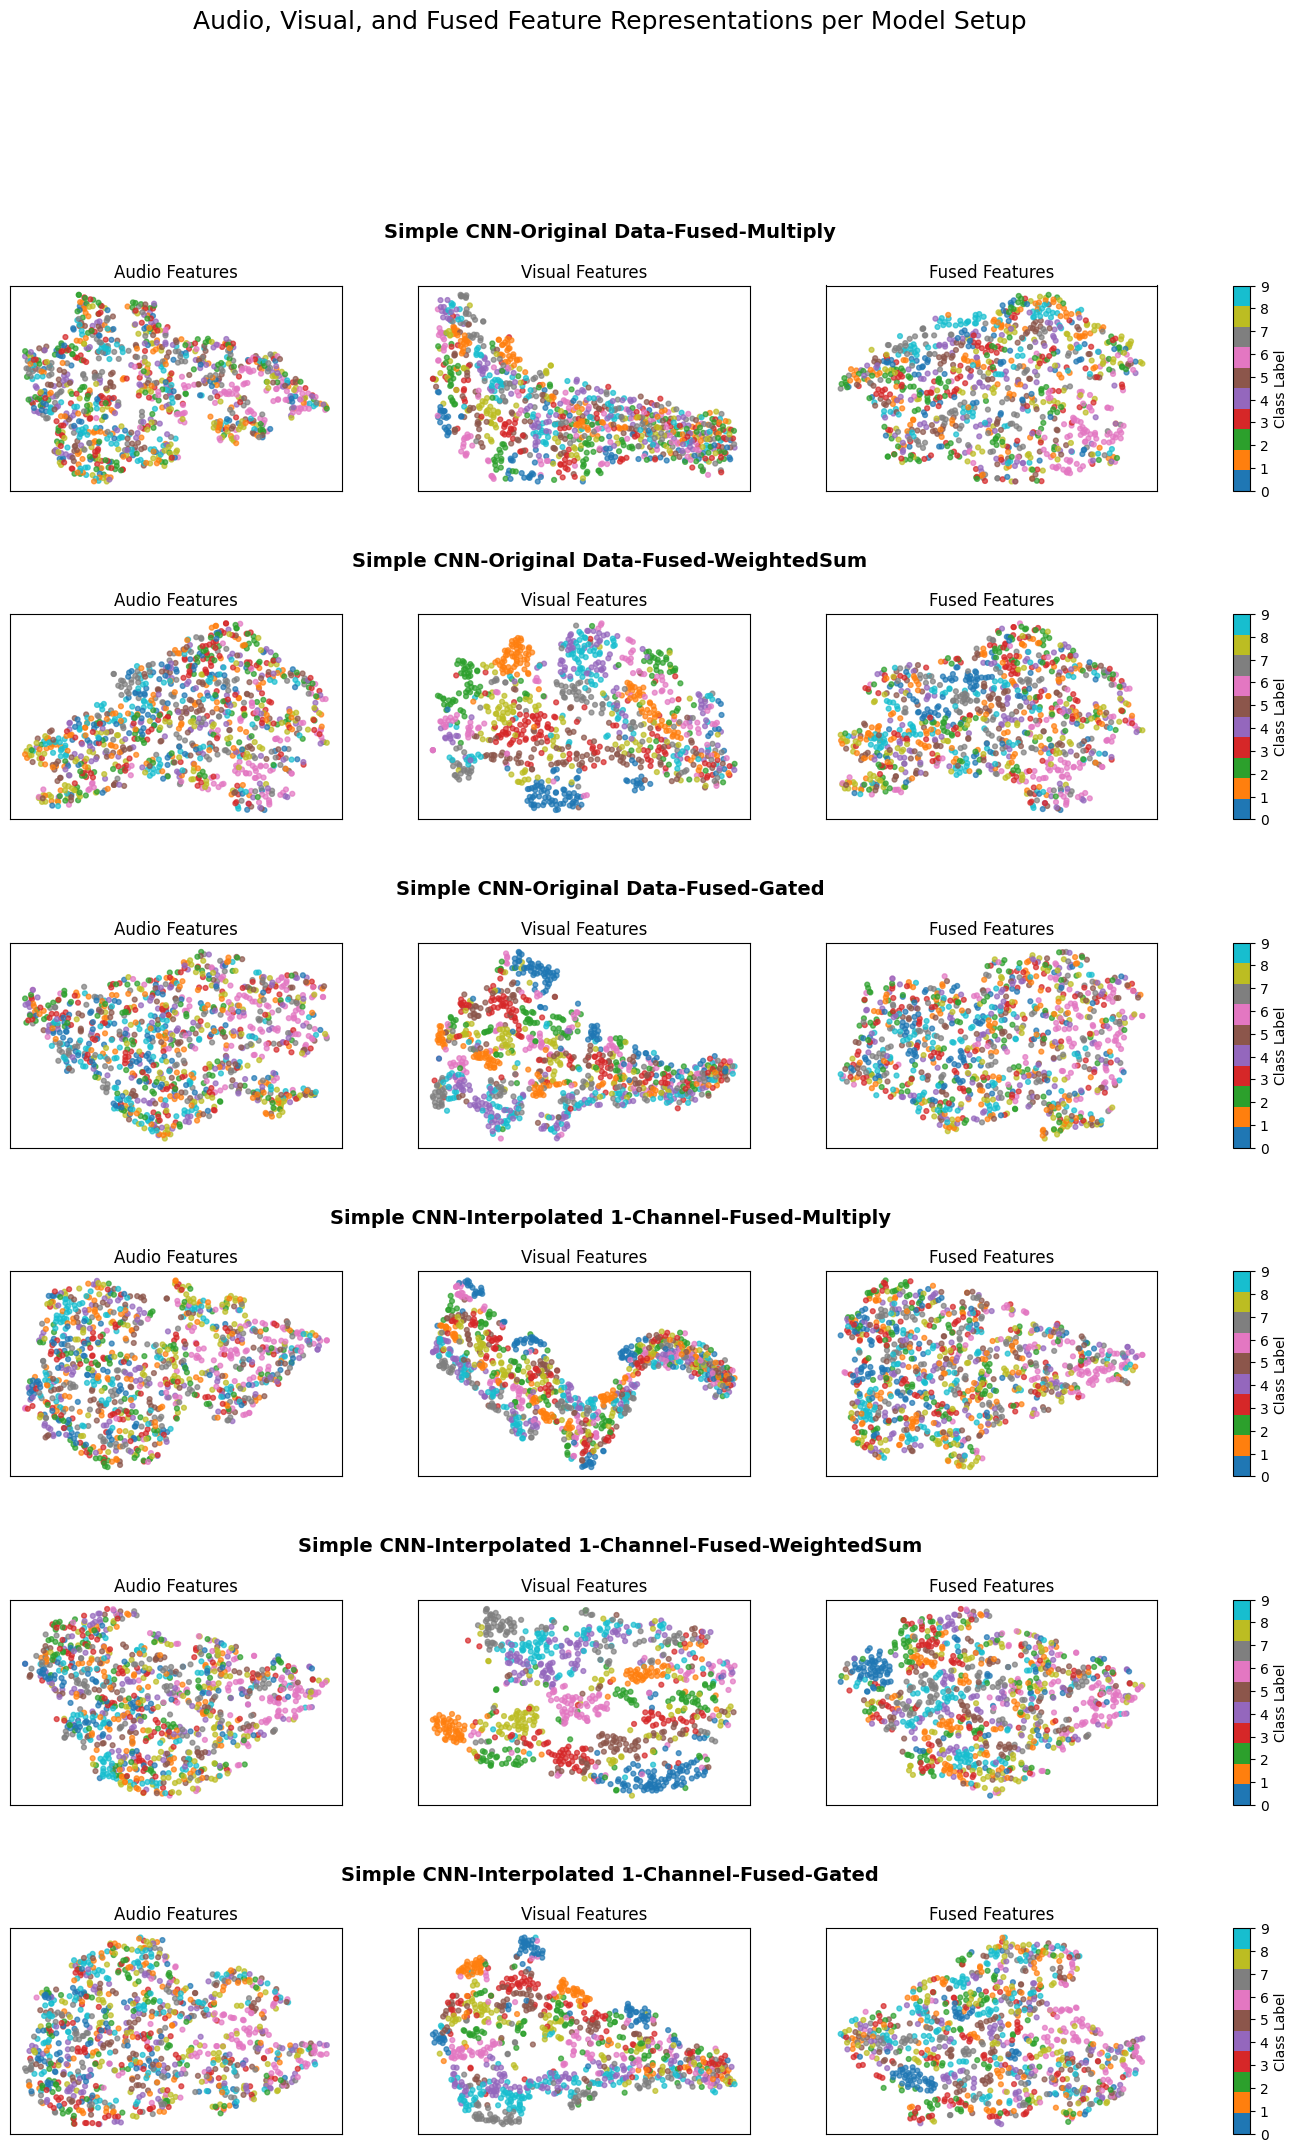

In [17]:
RESULTS_DIR = "NLDL_FYS-8604/images"

def visualize_representations_all_models(models_with_loaders_and_names, method="tsne", num_samples=500):
    import matplotlib.pyplot as plt
    import matplotlib.gridspec as gridspec
    from matplotlib import cm
    from matplotlib.colors import Normalize
    import numpy as np

    all_audio_2d = []
    all_visual_2d = []
    all_fused_2d = []
    all_labels = []
    all_names = []

    # Collect features
    for model, loader, name in models_with_loaders_and_names:
        model.eval()
        audio_feats, visual_feats, fused_feats, labels = [], [], [], []

        with torch.no_grad():
            for x, y in loader:
                x = {k: v.to(device) for k, v in x.items()}
                y = y.to(device)

                audio = x['audio_data']
                visual = x['visual_data']

                audio_out = model.audio_proj(model.audio_model(audio))
                visual_out = model.visual_proj(model.visual_model(visual))

                if model.fusion_method == 'concat':
                    fused = torch.cat((audio_out, visual_out), dim=1)
                elif model.fusion_method == 'sum':
                    fused = audio_out + visual_out
                elif model.fusion_method == 'multiply':
                    fused = audio_out * visual_out
                elif model.fusion_method == 'average':
                    fused = (audio_out + visual_out) / 2
                elif model.fusion_method == 'weighted_sum':
                    fused = model.alpha * audio_out + (1 - model.alpha) * visual_out
                elif model.fusion_method == 'gated':
                    gate = model.gate_layer(torch.cat((audio_out, visual_out), dim=1))
                    fused = gate * audio_out + (1 - gate) * visual_out
                else:
                    raise ValueError(f"Unknown fusion method '{model.fusion_method}'")

                audio_feats.append(audio_out.cpu())
                visual_feats.append(visual_out.cpu())
                fused_feats.append(fused.cpu())
                labels.append(y.cpu())

                if len(torch.cat(labels)) >= num_samples:
                    break

        audio_feats = torch.cat(audio_feats)[:num_samples]
        visual_feats = torch.cat(visual_feats)[:num_samples]
        fused_feats = torch.cat(fused_feats)[:num_samples]
        labels = torch.cat(labels)[:num_samples]

        reducer = TSNE(n_components=2, random_state=42) if method == "tsne" else PCA(n_components=2)
        audio_2d = reducer.fit_transform(audio_feats)
        visual_2d = reducer.fit_transform(visual_feats)
        fused_2d = reducer.fit_transform(fused_feats)

        all_audio_2d.append(audio_2d)
        all_visual_2d.append(visual_2d)
        all_fused_2d.append(fused_2d)
        all_labels.append(labels.numpy())
        all_names.append(name)

    n_models = len(all_names)
    fig = plt.figure(figsize=(16, 4 * n_models))
    outer_grid = gridspec.GridSpec(n_models, 1, wspace=0.3, hspace=0.6)

    for i in range(n_models):
        inner_grid = gridspec.GridSpecFromSubplotSpec(1, 4, subplot_spec=outer_grid[i], width_ratios=[1, 1, 1, 0.05], wspace=0.3)

        titles = ["Audio Features", "Visual Features", "Fused Features"]
        data_list = [all_audio_2d[i], all_visual_2d[i], all_fused_2d[i]]
        label_data = all_labels[i]

        for j in range(3):
            ax = plt.Subplot(fig, inner_grid[j])
            scatter = ax.scatter(data_list[j][:, 0], data_list[j][:, 1], c=label_data, cmap='tab10', s=12, alpha=0.7)
            ax.set_title(titles[j], fontsize=12)
            ax.set_xticks([])
            ax.set_yticks([])
            fig.add_subplot(ax)

        # Row title (above the 3 subplots)
        fig.text(0.5, outer_grid[i].get_position(fig).y1 + 0.02, all_names[i], ha='center', fontsize=14, fontweight='bold')

        # Colorbar to the right
        cax = plt.Subplot(fig, inner_grid[3])
        norm = Normalize(vmin=0, vmax=9)
        cb = fig.colorbar(cm.ScalarMappable(norm=norm, cmap='tab10'), cax=cax, ticks=range(10))
        cb.set_label('Class Label', fontsize=10)
        fig.add_subplot(cax)

    plt.title("", fontsize=0)
    fig.canvas.draw()
    fig.savefig(f"{RESULTS_DIR}/feature_representations_all_models.png", bbox_inches='tight', dpi=300)
    plt.suptitle("Audio, Visual, and Fused Feature Representations per Model Setup", fontsize=18, y=0.995)
    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.show()

visualize_representations_all_models(all_models, method="tsne", num_samples=1000)


<h3 style='color:#2e6c80;margin-bottom:8px'>Summary and Reflections</h3>
<div style='font-size:14px;line-height:1.4;margin-bottom:10px'>Summarize the findings from all tasks and reflect on what was learned.</div>
<ul style='margin-top:0px;margin-bottom:10px;padding-left:20px;font-size:13px;'>
<li>Which model performed best?</li>
<li>What are potential improvements for future work?</li>
</ul>

In [ ]:
# TODO: Summarize and conclude

<h3 style='color:#2e6c80;margin-bottom:8px'>Appendix</h3>
<div style='font-size:14px;line-height:1.4;margin-bottom:10px'>Include helper functions, model definitions, or any references used.</div>

In [ ]:
# TODO: Add helper code or resources